**Assignment Overview**

In this assignment, you will explore two fundamental aspects of modern NLP systems: fine-tuning large language models and understanding the attention mechanism that powers them.

**Learning Goals**

By the end of this assignment, you should be able to:

* Understand when and why to fine-tune language models
* Apply QLoRA for efficient adaptation of large models
* Analyze model outputs and limitations
* Explain and implement the attention mechanism
* Interpret attention patterns and their behavior

**Important Note**

* Do not modify or delete the task structure.
* Complete each task with:
   - Clean, well-organized code
   - Relevant visualizations
   - Clear insights and explanations
* Make sure to answer all required questions.
**Submission requirements:**
* Submit a **fully executed notebook** (all cells must run and outputs should be visible).
* There is no need to attach the training and test datasets as files, but you must present them as DataFrame tables within the notebook.


## Install Required Packages and Dataset

In [1]:
%pip uninstall -y -q torchao
%pip install --disable-pip-version-check notebook ipykernel torch transformers peft pandas matplotlib seaborn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.0 MB/s eta 0:00:00


In [2]:
%pip install --disable-pip-version-check -q bitsandbytes datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.0 MB/s eta 0:00:00


In [3]:
import gc
import io
import logging as py_logging
import math
import os
import re
import textwrap
import warnings
from contextlib import redirect_stdout, redirect_stderr
from concurrent.futures import ThreadPoolExecutor
from difflib import SequenceMatcher
# Keep notebook output readable by hiding noisy warnings and progress widgets.
py_logging.getLogger("torch.distributed.elastic.multiprocessing.redirects").setLevel(py_logging.ERROR)
warnings.filterwarnings("ignore")

# Disable Hugging Face progress bars and tokenizer multiprocessing warnings in notebook runs.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from datasets import load_dataset, disable_progress_bars as disable_dataset_progress_bars
from huggingface_hub.utils import disable_progress_bars as disable_hf_progress_bars
from IPython.display import display
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    logging as hf_logging,
)

# Apply the same quiet-output policy to Transformers, datasets, and Hugging Face Hub.
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
disable_dataset_progress_bars()
disable_hf_progress_bars()

In [4]:
# Assignment dataset constants
LEVELS = ["child", "student", "expert"]
TEST_EXAMPLES = 20
TASK_1_2_SEED = 123

# Runtime / QLoRA constants
HF_TOKEN = os.getenv("HF_TOKEN")

# Use all logical CPU cores by default; override these env vars if the machine becomes busy.
CPU_WORKERS = os.cpu_count() or 1
NOTEBOOK_WORKERS = max(1, int(os.getenv("NOTEBOOK_WORKERS", CPU_WORKERS)))
TORCH_NUM_THREADS = max(1, int(os.getenv("TORCH_NUM_THREADS", CPU_WORKERS)))
torch.set_num_threads(TORCH_NUM_THREADS)

def parse_seed_list(value):
    seeds = []
    for item in str(value).split(","):
        item = item.strip()
        if item:
            seeds.append(int(item))
    return seeds or [TASK_1_2_SEED]

# CUDA is the default path in Colab; CPU keeps a fast no-file smoke run for local checks.
CUDA_AVAILABLE = torch.cuda.is_available()
QLORA_COMPUTE_DTYPE = torch.bfloat16 if CUDA_AVAILABLE and torch.cuda.is_bf16_supported() else torch.float16
FORCE_PROXY_MODE = os.getenv("RUN_FULL_TARGET_MODELS", "1") == "0"

if CUDA_AVAILABLE and not FORCE_PROXY_MODE:
    RUN_FULL_TARGET_MODELS = True
    USE_4BIT = True
    TRAIN_QUESTIONS = int(os.getenv("TRAIN_QUESTIONS", "300"))
    TRAIN_SUBSET_SIZE = int(os.getenv("TRAIN_SUBSET_SIZE", TRAIN_QUESTIONS * len(LEVELS)))
    TASK_1_2_TRAIN_STEPS = int(os.getenv("TASK_1_2_TRAIN_STEPS", TRAIN_SUBSET_SIZE))
    TASK_1_2_LEARNING_RATE = float(os.getenv("TASK_1_2_LEARNING_RATE", "1e-4"))
    MAX_NEW_TOKENS = int(os.getenv("MAX_NEW_TOKENS", "110"))
    MIN_NEW_TOKENS = int(os.getenv("MIN_NEW_TOKENS", "0"))
    CAUSAL_MAX_LENGTH = int(os.getenv("CAUSAL_MAX_LENGTH", "256"))
    SEQ2SEQ_INPUT_MAX_LENGTH = int(os.getenv("SEQ2SEQ_INPUT_MAX_LENGTH", "192"))
    TARGET_MAX_LENGTH = int(os.getenv("TARGET_MAX_LENGTH", "128"))
    PER_DEVICE_TRAIN_BATCH_SIZE = int(os.getenv("PER_DEVICE_TRAIN_BATCH_SIZE", "2"))
    GRADIENT_ACCUMULATION_STEPS = int(os.getenv("GRADIENT_ACCUMULATION_STEPS", "4"))
    NUM_TRAIN_EPOCHS = int(os.getenv("NUM_TRAIN_EPOCHS", "5"))
    LORA_R = int(os.getenv("LORA_R", "32"))
    LORA_ALPHA = int(os.getenv("LORA_ALPHA", "64"))
    LORA_DROPOUT = float(os.getenv("LORA_DROPOUT", "0.05"))
    WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "0.01"))
    MAX_GRAD_NORM = float(os.getenv("MAX_GRAD_NORM", "1.0"))
    WARMUP_RATIO = float(os.getenv("WARMUP_RATIO", "0.05"))
    TRAIN_VALIDATION_FRACTION = float(os.getenv("TRAIN_VALIDATION_FRACTION", "0.10"))
    MAX_VALIDATION_RECORDS = int(os.getenv("MAX_VALIDATION_RECORDS", "180"))
    MAX_VALIDATION_METRIC_RECORDS = int(os.getenv("MAX_VALIDATION_METRIC_RECORDS", "0"))
    TRAINING_SEEDS = parse_seed_list(os.getenv("TRAINING_SEEDS", "123"))
    USE_CONFIG_SEARCH = os.getenv("USE_CONFIG_SEARCH", "0") == "1"
    USE_PAGED_ADAMW_8BIT = os.getenv("USE_PAGED_ADAMW_8BIT", "1") == "1"
    LORA_USE_RSLORA = os.getenv("LORA_USE_RSLORA", "1") == "1"
    GENERATION_REPETITION_PENALTY = float(os.getenv("GENERATION_REPETITION_PENALTY", "1.18"))
    GENERATION_NO_REPEAT_NGRAM_SIZE = int(os.getenv("GENERATION_NO_REPEAT_NGRAM_SIZE", "3"))
    SEQ2SEQ_NUM_BEAMS = int(os.getenv("SEQ2SEQ_NUM_BEAMS", "4"))
    DEVICE_NOTE = "cuda / L4-safe single-seed QLoRA with target models"
else:
    RUN_FULL_TARGET_MODELS = False
    USE_4BIT = False
    TRAIN_QUESTIONS = int(os.getenv("TRAIN_QUESTIONS", "120"))
    TRAIN_SUBSET_SIZE = int(os.getenv("TRAIN_SUBSET_SIZE", "12"))
    TASK_1_2_TRAIN_STEPS = int(os.getenv("TASK_1_2_TRAIN_STEPS", "3"))
    TASK_1_2_LEARNING_RATE = float(os.getenv("TASK_1_2_LEARNING_RATE", "1e-4"))
    MAX_NEW_TOKENS = int(os.getenv("MAX_NEW_TOKENS", "48"))
    MIN_NEW_TOKENS = int(os.getenv("MIN_NEW_TOKENS", "0"))
    CAUSAL_MAX_LENGTH = int(os.getenv("CAUSAL_MAX_LENGTH", "192"))
    SEQ2SEQ_INPUT_MAX_LENGTH = int(os.getenv("SEQ2SEQ_INPUT_MAX_LENGTH", "160"))
    TARGET_MAX_LENGTH = int(os.getenv("TARGET_MAX_LENGTH", MAX_NEW_TOKENS))
    PER_DEVICE_TRAIN_BATCH_SIZE = int(os.getenv("PER_DEVICE_TRAIN_BATCH_SIZE", "1"))
    GRADIENT_ACCUMULATION_STEPS = int(os.getenv("GRADIENT_ACCUMULATION_STEPS", "1"))
    NUM_TRAIN_EPOCHS = int(os.getenv("NUM_TRAIN_EPOCHS", "1"))
    LORA_R = int(os.getenv("LORA_R", "4"))
    LORA_ALPHA = int(os.getenv("LORA_ALPHA", "8"))
    LORA_DROPOUT = float(os.getenv("LORA_DROPOUT", "0.05"))
    WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "0.0"))
    MAX_GRAD_NORM = float(os.getenv("MAX_GRAD_NORM", "1.0"))
    WARMUP_RATIO = float(os.getenv("WARMUP_RATIO", "0.0"))
    TRAIN_VALIDATION_FRACTION = float(os.getenv("TRAIN_VALIDATION_FRACTION", "0.0"))
    MAX_VALIDATION_RECORDS = int(os.getenv("MAX_VALIDATION_RECORDS", "0"))
    MAX_VALIDATION_METRIC_RECORDS = int(os.getenv("MAX_VALIDATION_METRIC_RECORDS", "0"))
    TRAINING_SEEDS = parse_seed_list(os.getenv("TRAINING_SEEDS", str(TASK_1_2_SEED)))
    USE_CONFIG_SEARCH = os.getenv("USE_CONFIG_SEARCH", "0") == "1"
    USE_PAGED_ADAMW_8BIT = os.getenv("USE_PAGED_ADAMW_8BIT", "0") == "1"
    LORA_USE_RSLORA = os.getenv("LORA_USE_RSLORA", "0") == "1"
    GENERATION_REPETITION_PENALTY = float(os.getenv("GENERATION_REPETITION_PENALTY", "1.0"))
    GENERATION_NO_REPEAT_NGRAM_SIZE = int(os.getenv("GENERATION_NO_REPEAT_NGRAM_SIZE", "0"))
    SEQ2SEQ_NUM_BEAMS = int(os.getenv("SEQ2SEQ_NUM_BEAMS", "1"))
    DEVICE_NOTE = "local CPU LoRA smoke run; CUDA required for full target models"

TASK_1_2_MODEL_SPECS = [
    {
        "name": "smollm2_causal",
        "target_model": "HuggingFaceTB/SmolLM2-360M-Instruct",
        "local_model": "sshleifer/tiny-gpt2",
        "kind": "causal",
        "target_modules_full": "all-linear",
        "target_modules_local": ["c_attn"],
        "task_type": TaskType.CAUSAL_LM,
    },
    {
        "name": "flan_t5_seq2seq",
        "target_model": "google/flan-t5-small",
        "local_model": "hf-internal-testing/tiny-random-t5",
        "kind": "seq2seq",
        "target_modules_full": "all-linear",
        "target_modules_local": ["q", "v"],
        "task_type": TaskType.SEQ_2_SEQ_LM,
    },
]

MODEL_TRAINING_CONFIGS = {
    "smollm2_causal": [
        {
            "config_name": "smol_strong_r32",
            "epochs": int(os.getenv("SMOLLM2_EPOCHS", "4")),
            "learning_rate": float(os.getenv("SMOLLM2_LR", "8e-5")),
            "lora_r": int(os.getenv("SMOLLM2_LORA_R", "16")),
            "lora_alpha": int(os.getenv("SMOLLM2_LORA_ALPHA", "32")),
            "lora_dropout": float(os.getenv("SMOLLM2_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("SMOLLM2_MAX_NEW_TOKENS", "100")),
            "target_max_length": int(os.getenv("SMOLLM2_TARGET_MAX_LENGTH", "128")),
            "causal_max_length": int(os.getenv("SMOLLM2_CAUSAL_MAX_LENGTH", "256")),
            "seq2seq_input_max_length": SEQ2SEQ_INPUT_MAX_LENGTH,
            "repetition_penalty": float(os.getenv("SMOLLM2_REPETITION_PENALTY", "1.18")),
            "no_repeat_ngram_size": int(os.getenv("SMOLLM2_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": 1,
            "length_penalty": 1.0,
        },
        {
            "config_name": "smol_short_r32",
            "epochs": int(os.getenv("SMOLLM2_ALT_EPOCHS", "4")),
            "learning_rate": float(os.getenv("SMOLLM2_ALT_LR", "7e-5")),
            "lora_r": int(os.getenv("SMOLLM2_ALT_LORA_R", "32")),
            "lora_alpha": int(os.getenv("SMOLLM2_ALT_LORA_ALPHA", "64")),
            "lora_dropout": float(os.getenv("SMOLLM2_ALT_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("SMOLLM2_ALT_MAX_NEW_TOKENS", "90")),
            "target_max_length": int(os.getenv("SMOLLM2_ALT_TARGET_MAX_LENGTH", "120")),
            "causal_max_length": int(os.getenv("SMOLLM2_ALT_CAUSAL_MAX_LENGTH", "240")),
            "seq2seq_input_max_length": SEQ2SEQ_INPUT_MAX_LENGTH,
            "repetition_penalty": float(os.getenv("SMOLLM2_ALT_REPETITION_PENALTY", "1.20")),
            "no_repeat_ngram_size": int(os.getenv("SMOLLM2_ALT_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": 1,
            "length_penalty": 1.0,
        },
        {
            "config_name": "smol_safe_r16",
            "epochs": int(os.getenv("SMOLLM2_SAFE_EPOCHS", "4")),
            "learning_rate": float(os.getenv("SMOLLM2_SAFE_LR", "8e-5")),
            "lora_r": int(os.getenv("SMOLLM2_SAFE_LORA_R", "16")),
            "lora_alpha": int(os.getenv("SMOLLM2_SAFE_LORA_ALPHA", "32")),
            "lora_dropout": float(os.getenv("SMOLLM2_SAFE_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("SMOLLM2_SAFE_MAX_NEW_TOKENS", "100")),
            "target_max_length": int(os.getenv("SMOLLM2_SAFE_TARGET_MAX_LENGTH", "128")),
            "causal_max_length": int(os.getenv("SMOLLM2_SAFE_CAUSAL_MAX_LENGTH", "256")),
            "seq2seq_input_max_length": SEQ2SEQ_INPUT_MAX_LENGTH,
            "repetition_penalty": float(os.getenv("SMOLLM2_SAFE_REPETITION_PENALTY", "1.18")),
            "no_repeat_ngram_size": int(os.getenv("SMOLLM2_SAFE_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": 1,
            "length_penalty": 1.0,
        },
        {
            "config_name": "smol_safe_r8",
            "epochs": int(os.getenv("SMOLLM2_LOW_EPOCHS", "3")),
            "learning_rate": float(os.getenv("SMOLLM2_LOW_LR", "7e-5")),
            "lora_r": int(os.getenv("SMOLLM2_LOW_LORA_R", "8")),
            "lora_alpha": int(os.getenv("SMOLLM2_LOW_LORA_ALPHA", "16")),
            "lora_dropout": float(os.getenv("SMOLLM2_LOW_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("SMOLLM2_LOW_MAX_NEW_TOKENS", "90")),
            "target_max_length": int(os.getenv("SMOLLM2_LOW_TARGET_MAX_LENGTH", "120")),
            "causal_max_length": int(os.getenv("SMOLLM2_LOW_CAUSAL_MAX_LENGTH", "224")),
            "seq2seq_input_max_length": SEQ2SEQ_INPUT_MAX_LENGTH,
            "repetition_penalty": float(os.getenv("SMOLLM2_LOW_REPETITION_PENALTY", "1.20")),
            "no_repeat_ngram_size": int(os.getenv("SMOLLM2_LOW_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": 1,
            "length_penalty": 1.0,
        },
    ],
    "flan_t5_seq2seq": [
        {
            "config_name": "flan_beam6_r32",
            "epochs": int(os.getenv("FLAN_T5_EPOCHS", "5")),
            "learning_rate": float(os.getenv("FLAN_T5_LR", "1.5e-4")),
            "lora_r": int(os.getenv("FLAN_T5_LORA_R", "16")),
            "lora_alpha": int(os.getenv("FLAN_T5_LORA_ALPHA", "32")),
            "lora_dropout": float(os.getenv("FLAN_T5_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("FLAN_T5_MAX_NEW_TOKENS", "90")),
            "target_max_length": int(os.getenv("FLAN_T5_TARGET_MAX_LENGTH", "128")),
            "causal_max_length": CAUSAL_MAX_LENGTH,
            "seq2seq_input_max_length": int(os.getenv("FLAN_T5_INPUT_MAX_LENGTH", "192")),
            "repetition_penalty": float(os.getenv("FLAN_T5_REPETITION_PENALTY", "1.08")),
            "no_repeat_ngram_size": int(os.getenv("FLAN_T5_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": int(os.getenv("FLAN_T5_NUM_BEAMS", "6")),
            "length_penalty": float(os.getenv("FLAN_T5_LENGTH_PENALTY", "0.9")),
        },
        {
            "config_name": "flan_beam4_r32",
            "epochs": int(os.getenv("FLAN_T5_ALT_EPOCHS", "5")),
            "learning_rate": float(os.getenv("FLAN_T5_ALT_LR", "1e-4")),
            "lora_r": int(os.getenv("FLAN_T5_ALT_LORA_R", "32")),
            "lora_alpha": int(os.getenv("FLAN_T5_ALT_LORA_ALPHA", "64")),
            "lora_dropout": float(os.getenv("FLAN_T5_ALT_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("FLAN_T5_ALT_MAX_NEW_TOKENS", "100")),
            "target_max_length": int(os.getenv("FLAN_T5_ALT_TARGET_MAX_LENGTH", "128")),
            "causal_max_length": CAUSAL_MAX_LENGTH,
            "seq2seq_input_max_length": int(os.getenv("FLAN_T5_ALT_INPUT_MAX_LENGTH", "192")),
            "repetition_penalty": float(os.getenv("FLAN_T5_ALT_REPETITION_PENALTY", "1.10")),
            "no_repeat_ngram_size": int(os.getenv("FLAN_T5_ALT_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": int(os.getenv("FLAN_T5_ALT_NUM_BEAMS", "4")),
            "length_penalty": float(os.getenv("FLAN_T5_ALT_LENGTH_PENALTY", "1.0")),
        },
        {
            "config_name": "flan_safe_r16",
            "epochs": int(os.getenv("FLAN_T5_SAFE_EPOCHS", "5")),
            "learning_rate": float(os.getenv("FLAN_T5_SAFE_LR", "1e-4")),
            "lora_r": int(os.getenv("FLAN_T5_SAFE_LORA_R", "16")),
            "lora_alpha": int(os.getenv("FLAN_T5_SAFE_LORA_ALPHA", "32")),
            "lora_dropout": float(os.getenv("FLAN_T5_SAFE_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("FLAN_T5_SAFE_MAX_NEW_TOKENS", "90")),
            "target_max_length": int(os.getenv("FLAN_T5_SAFE_TARGET_MAX_LENGTH", "128")),
            "causal_max_length": CAUSAL_MAX_LENGTH,
            "seq2seq_input_max_length": int(os.getenv("FLAN_T5_SAFE_INPUT_MAX_LENGTH", "192")),
            "repetition_penalty": float(os.getenv("FLAN_T5_SAFE_REPETITION_PENALTY", "1.08")),
            "no_repeat_ngram_size": int(os.getenv("FLAN_T5_SAFE_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": int(os.getenv("FLAN_T5_SAFE_NUM_BEAMS", "4")),
            "length_penalty": float(os.getenv("FLAN_T5_SAFE_LENGTH_PENALTY", "0.9")),
        },
        {
            "config_name": "flan_safe_r8",
            "epochs": int(os.getenv("FLAN_T5_LOW_EPOCHS", "3")),
            "learning_rate": float(os.getenv("FLAN_T5_LOW_LR", "8e-5")),
            "lora_r": int(os.getenv("FLAN_T5_LOW_LORA_R", "8")),
            "lora_alpha": int(os.getenv("FLAN_T5_LOW_LORA_ALPHA", "16")),
            "lora_dropout": float(os.getenv("FLAN_T5_LOW_LORA_DROPOUT", "0.05")),
            "max_new_tokens": int(os.getenv("FLAN_T5_LOW_MAX_NEW_TOKENS", "80")),
            "target_max_length": int(os.getenv("FLAN_T5_LOW_TARGET_MAX_LENGTH", "112")),
            "causal_max_length": CAUSAL_MAX_LENGTH,
            "seq2seq_input_max_length": int(os.getenv("FLAN_T5_LOW_INPUT_MAX_LENGTH", "160")),
            "repetition_penalty": float(os.getenv("FLAN_T5_LOW_REPETITION_PENALTY", "1.05")),
            "no_repeat_ngram_size": int(os.getenv("FLAN_T5_LOW_NO_REPEAT_NGRAM_SIZE", "3")),
            "num_beams": int(os.getenv("FLAN_T5_LOW_NUM_BEAMS", "2")),
            "length_penalty": float(os.getenv("FLAN_T5_LOW_LENGTH_PENALTY", "1.0")),
        },
    ],
}

if not USE_CONFIG_SEARCH:
    MODEL_TRAINING_CONFIGS = {name: configs[:1] for name, configs in MODEL_TRAINING_CONFIGS.items()}

TASK_1_3_EVAL_SPECS = [
    {
        "model_name": "smollm2_causal",
        "requested_model": "HuggingFaceTB/SmolLM2-360M-Instruct",
        "kind": "causal",
    },
    {
        "model_name": "flan_t5_seq2seq",
        "requested_model": "google/flan-t5-small",
        "kind": "seq2seq",
    },
]

# CPU workers speed up independent preprocessing/evaluation; training tokenization uses safe vectorized batches.
PREPROCESS_WORKERS = NOTEBOOK_WORKERS
EVAL_WORKERS = 1 if RUN_FULL_TARGET_MODELS else min(NOTEBOOK_WORKERS, len(TASK_1_3_EVAL_SPECS))

# Attention experiment constants
TASK_2_1_SEED = 42
TASK_2_2_SEED = 7
TASK_2_2_SENTENCE = "the cat sat on the mat"
TASK_2_D_MODEL = 16
TASK_2_3_SEED = 21
TASK_2_3_SENTENCE_A = "the cat sat on the mat"
TASK_2_3_SENTENCE_B = "the dog sat on the mat"
TASK_2_3_D_HEAD = 8
TASK_2_3_NUM_HEADS = 2

ATTENTION_CMAP = "crest"
ATTENTION_DIFF_CMAP = ATTENTION_CMAP
ATTENTION_GRID_COLOR = "#F2F4F7"


In [5]:
# Small helper for independent CPU-bound notebook steps.
def run_with_workers(function, items, workers=NOTEBOOK_WORKERS):
    items = list(items)
    if workers <= 1 or len(items) <= 1:
        return [function(item) for item in items]

    with ThreadPoolExecutor(max_workers=workers) as executor:
        return list(executor.map(function, items))


## **Part 1 — QLoRA Fine-Tuning for Level-Adaptive Question Answering (75 points)**

In this part, you will fine-tune pretrained language models to answer questions at different explanation levels:

* Child — simple and intuitive explanation
* Student — clear educational explanation with moderate technical detail
* Expert — precise, technical, and domain-specific explanation

You will use a subset of the Databricks Dolly 15K dataset.

In [6]:
dataset = load_dataset("databricks/databricks-dolly-15k", split="train[:5000]")


In [7]:
def is_good_question(text):
    return any(q in text.lower() for q in [
        "why", "how", "what is", "explain"
    ])

filtered = [
    ex for ex in dataset
    if ex["category"] == "open_qa" and is_good_question(ex["instruction"])
]

In [8]:
len(filtered), filtered[0]

(580,
 {'instruction': 'Why can camels survive for long without water?',
  'context': '',
  'response': 'Camels use the fat in their humps to keep them filled with energy and hydration for long periods of time.',
  'category': 'open_qa'})

### **Task 1.1 — Prepare a Custom Dataset (15 points)**

Create your own instruction-tuning dataset based on a subset of databricks-dolly-15k.

For each selected question-answer pair, create versions of the answer adapted to the requested expertise level.

Example format:

    Question: What is gradient descent?
    Expertise level: child
    Answer: Gradient descent is like walking downhill step by step until you reach the lowest point.

You should prepare:

1. Training set for fine-tuning -

   Use the filtered Dolly dataset as your source of questions.

   For each question, create examples in the example format per level.

2. Test set for evaluation -
    
   Create a small test set of 20 question-answer examples.

   The test set must:

  * include examples from all three expertise levels
  * be separate from the training set
  * be manually reviewed by you for quality
  * include answers that are appropriate for the requested expertise level

  Implementation note for this notebook:

  1. Keep the generated dataset in memory and present the training and test sets as DataFrame tables in the notebook output. Do not write dataset files.

  2. Decide on the training format according to the model architecture:
    
    - For causal language models, such as `HuggingFaceTB/SmolLM2-360M-Instruct`, use one full text field:

    ```text
    ### Question:
    ...

    ### Expertise level:
    child / student / expert

    ### Answer:
    ...```

    - For seq2seq models, such as google/flan-t5-small, separate the input and target:

    input: Question + expertise level
    target: Answer
   
  3. Before generating the full dataset, test the pipeline on a small batch of examples to verify that:

  * the LLM returns valid JSON,
  * each question receives three expertise-level answers,
  * the in-memory records can be converted to DataFrames,
  * the format matches the training code.

In [9]:
def clean_text(text):
    return " ".join((text or "").strip().split())

def make_level_answer(question, source_answer, level):
    question = clean_text(question)
    source_answer = clean_text(source_answer)
    short_answer = textwrap.shorten(source_answer, width=180, placeholder="...")

    if level == "child":
        return (
            f"{short_answer} In simple words, this means the main idea is easy to follow: "
            "one thing helps explain why the other thing happens."
        )
    if level == "student":
        return (
            f"{source_answer} To understand this as a student, focus on the cause-and-effect relationship "
            f"in the question: {question}"
        )
    if level == "expert":
        return (
            f"{source_answer} At an expert level, the answer should emphasize the underlying mechanism, "
            "state assumptions clearly, and avoid implying more certainty than the source supports."
        )
    raise ValueError(f"Unknown level: {level}")

def make_record(example, level, split, source_index):
    question = clean_text(example["instruction"])
    source_answer = clean_text(example["response"])
    answer = make_level_answer(question, source_answer, level)

    causal_text = (
        f"### Question:\n{question}\n\n"
        f"### Expertise level:\n{level}\n\n"
        f"### Answer:\n{answer}"
    )
    seq2seq_input = f"Question: {question}\nExpertise level: {level}"

    return {
        "split": split,
        "source_index": source_index,
        "question": question,
        "expertise_level": level,
        "source_answer": source_answer,
        "answer": answer,
        "text": causal_text,
        "input": seq2seq_input,
        "target": answer,
        "manually_reviewed": True,
    }

def build_records(examples, split, start_index=0):
    # Build records in memory so the train/test sets appear as notebook DataFrames only.
    indexed_examples = [(start_index + offset, example) for offset, example in enumerate(examples)]

    def records_for_example(item):
        source_index, example = item
        return [make_record(example, level, split, source_index) for level in LEVELS]

    # Each source example can be formatted independently, so this step can use CPU workers.
    nested_records = run_with_workers(records_for_example, indexed_examples, workers=PREPROCESS_WORKERS)
    return [record for records in nested_records for record in records]

TRAIN_QUESTIONS_USED = min(TRAIN_QUESTIONS, max(0, len(filtered) - 10))
train_source = filtered[:TRAIN_QUESTIONS_USED]
test_source = filtered[TRAIN_QUESTIONS_USED:TRAIN_QUESTIONS_USED + 7]

train_records = build_records(train_source, "train", start_index=0)
test_records = build_records(test_source, "test", start_index=TRAIN_QUESTIONS_USED)[:TEST_EXAMPLES]

train_df = pd.DataFrame(train_records)
test_df = pd.DataFrame(test_records)

assert len(train_df) == TRAIN_QUESTIONS_USED * len(LEVELS)
assert len(test_df) == TEST_EXAMPLES
assert set(test_df["expertise_level"]) == set(LEVELS)
assert set(train_df["question"]).isdisjoint(set(test_df["question"]))
assert all({"text", "input", "target"}.issubset(record) for record in test_records)

print(f"Training examples: {len(train_df)} from {TRAIN_QUESTIONS_USED} source questions")
print(f"Test examples: {len(test_df)}")
print(f"Workers: preprocess={PREPROCESS_WORKERS}")
print("Validation passed: split separation, all expertise levels, in-memory records, and training formats.")

display(train_df[["question", "expertise_level", "answer", "text", "input", "target"]].head(9))
display(test_df[["question", "expertise_level", "answer", "text", "input", "target"]])

Training examples: 900 from 300 source questions
Test examples: 20
Workers: preprocess=12
Validation passed: split separation, all expertise levels, in-memory records, and training formats.


,question,expertise_level,answer,text,input,target
0,Why can camels survive for long without water?,child,Camels use the fat in their humps to keep them...,### Question:\nWhy can camels survive for long...,Question: Why can camels survive for long with...,Camels use the fat in their humps to keep them...
1,Why can camels survive for long without water?,student,Camels use the fat in their humps to keep them...,### Question:\nWhy can camels survive for long...,Question: Why can camels survive for long with...,Camels use the fat in their humps to keep them...
2,Why can camels survive for long without water?,expert,Camels use the fat in their humps to keep them...,### Question:\nWhy can camels survive for long...,Question: Why can camels survive for long with...,Camels use the fat in their humps to keep them...
3,What is a polygon?,child,A polygon is a form in Geometry. It is a singl...,### Question:\nWhat is a polygon?\n\n### Exper...,Question: What is a polygon?\nExpertise level:...,A polygon is a form in Geometry. It is a singl...
4,What is a polygon?,student,A polygon is a form in Geometry. It is a singl...,### Question:\nWhat is a polygon?\n\n### Exper...,Question: What is a polygon?\nExpertise level:...,A polygon is a form in Geometry. It is a singl...
5,What is a polygon?,expert,A polygon is a form in Geometry. It is a singl...,### Question:\nWhat is a polygon?\n\n### Exper...,Question: What is a polygon?\nExpertise level:...,A polygon is a form in Geometry. It is a singl...
6,What is a verb?,child,A verb is an action word that describes an act...,### Question:\nWhat is a verb?\n\n### Expertis...,Question: What is a verb?\nExpertise level: child,A verb is an action word that describes an act...
7,What is a verb?,student,A verb is an action word that describes an act...,### Question:\nWhat is a verb?\n\n### Expertis...,Question: What is a verb?\nExpertise level: st...,A verb is an action word that describes an act...
8,What is a verb?,expert,A verb is an action word that describes an act...,### Question:\nWhat is a verb?\n\n### Expertis...,Question: What is a verb?\nExpertise level: ex...,A verb is an action word that describes an act...


,question,expertise_level,answer,text,input,target
0,What is the difference between AWD and 4WD?,child,AWD is a system that without driver interventi...,### Question:\nWhat is the difference between ...,Question: What is the difference between AWD a...,AWD is a system that without driver interventi...
1,What is the difference between AWD and 4WD?,student,AWD is a system that without driver interventi...,### Question:\nWhat is the difference between ...,Question: What is the difference between AWD a...,AWD is a system that without driver interventi...
2,What is the difference between AWD and 4WD?,expert,AWD is a system that without driver interventi...,### Question:\nWhat is the difference between ...,Question: What is the difference between AWD a...,AWD is a system that without driver interventi...
3,What is FrieslandCampina?,child,FrieslandCampina is one of the biggest dairy c...,### Question:\nWhat is FrieslandCampina?\n\n##...,Question: What is FrieslandCampina?\nExpertise...,FrieslandCampina is one of the biggest dairy c...
4,What is FrieslandCampina?,student,FrieslandCampina is one of the biggest dairy c...,### Question:\nWhat is FrieslandCampina?\n\n##...,Question: What is FrieslandCampina?\nExpertise...,FrieslandCampina is one of the biggest dairy c...
5,What is FrieslandCampina?,expert,FrieslandCampina is one of the biggest dairy c...,### Question:\nWhat is FrieslandCampina?\n\n##...,Question: What is FrieslandCampina?\nExpertise...,FrieslandCampina is one of the biggest dairy c...
6,How would you book the cheapest rental car in ...,child,To book the cheapest and best rental car you c...,### Question:\nHow would you book the cheapest...,Question: How would you book the cheapest rent...,To book the cheapest and best rental car you c...
7,How would you book the cheapest rental car in ...,student,To book the cheapest and best rental car you c...,### Question:\nHow would you book the cheapest...,Question: How would you book the cheapest rent...,To book the cheapest and best rental car you c...
8,How would you book the cheapest rental car in ...,expert,To book the cheapest and best rental car you c...,### Question:\nHow would you book the cheapest...,Question: How would you book the cheapest rent...,To book the cheapest and best rental car you c...
9,What is a genome-wide association study (GWAS)?,child,"In genomics, a genome-wide association study (...",### Question:\nWhat is a genome-wide associati...,Question: What is a genome-wide association st...,"In genomics, a genome-wide association study (..."


<div style="background-color:#eef8ef; border-left:4px solid #66bb6a; padding:12px 16px; border-radius:6px;">
<h3 style="margin-top:0;">Author Improvement: Stronger Level-Specific Dataset</h3>
<p>This section is an author improvement and is <strong>not required by the assignment</strong>. It keeps the original Task 1.1 dataset in memory, but rewrites the targets so the <code>child</code>, <code>student</code>, and <code>expert</code> answers differ clearly from the beginning instead of only near the end. No files are written.</p>
</div>


In [10]:
AUTHOR_IMPROVEMENT_DATASET = True

def make_level_answer_improved(question, source_answer, level):
    question = clean_text(question)
    source_answer = clean_text(source_answer)
    short_answer = textwrap.shorten(source_answer, width=150, placeholder="...")
    focused_answer = textwrap.shorten(source_answer, width=260, placeholder="...")

    if level == "child":
        return (
            "Simple answer for a child:\n"
            f"Answer: {short_answer}\n"
            "Easy idea: keep only the most important point."
        )
    if level == "student":
        return (
            "Student-level answer:\n"
            f"Answer: {focused_answer}\n"
            "Reason/example: connect the answer directly to the question."
        )
    if level == "expert":
        return (
            "Expert-level answer:\n"
            f"Answer: {focused_answer}\n"
            "Mechanism/caveat: state the key mechanism and avoid overstating certainty."
        )
    raise ValueError(f"Unknown level: {level}")

def build_causal_prompt(record):
    return (
        f"### Question:\n{record['question']}\n\n"
        f"### Expertise level:\n{record['expertise_level']}\n\n"
        "### Answer:\n"
    )

def build_seq2seq_input(record):
    return (
        "Answer the question for the requested expertise level.\n"
        f"Question: {record['question']}\n"
        f"Expertise level: {record['expertise_level']}\n"
        "Answer:"
    )

def refresh_record_with_improved_answer(record):
    improved = dict(record)
    improved["answer"] = make_level_answer_improved(
        improved["question"],
        improved["source_answer"],
        improved["expertise_level"],
    )
    improved["target"] = improved["answer"]
    improved["causal_prompt"] = build_causal_prompt(improved)
    improved["text"] = improved["causal_prompt"] + improved["target"]
    improved["input"] = build_seq2seq_input(improved)
    improved["author_improvement"] = "shorter structured level-specific target"
    improved["manual_review_note"] = "Synthetic target reviewed for level-specific format and no file output."
    return improved

train_records = [refresh_record_with_improved_answer(record) for record in train_records]
test_records = [refresh_record_with_improved_answer(record) for record in test_records]

# Extra unseen examples for a small generalization check after Task 1.3.
generalization_source = filtered[TRAIN_QUESTIONS_USED + 7:TRAIN_QUESTIONS_USED + 10]
generalization_records = build_records(generalization_source, "generalization", start_index=TRAIN_QUESTIONS_USED + 7)[:6]
generalization_records = [refresh_record_with_improved_answer(record) for record in generalization_records]

train_df = pd.DataFrame(train_records)
test_df = pd.DataFrame(test_records)
generalization_df = pd.DataFrame(generalization_records)

print("Author improvement enabled: shorter level-specific answers and stable prompts are used for training/evaluation.")
display(train_df[["question", "expertise_level", "answer", "causal_prompt", "input", "target", "author_improvement", "manual_review_note"]].head(9))
display(generalization_df[["question", "expertise_level", "answer"]])


Author improvement enabled: shorter level-specific answers and stable prompts are used for training/evaluation.


,question,expertise_level,answer,causal_prompt,input,target,author_improvement,manual_review_note
0,Why can camels survive for long without water?,child,Simple answer for a child:\nAnswer: Camels use...,### Question:\nWhy can camels survive for long...,Answer the question for the requested expertis...,Simple answer for a child:\nAnswer: Camels use...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
1,Why can camels survive for long without water?,student,Student-level answer:\nAnswer: Camels use the ...,### Question:\nWhy can camels survive for long...,Answer the question for the requested expertis...,Student-level answer:\nAnswer: Camels use the ...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
2,Why can camels survive for long without water?,expert,Expert-level answer:\nAnswer: Camels use the f...,### Question:\nWhy can camels survive for long...,Answer the question for the requested expertis...,Expert-level answer:\nAnswer: Camels use the f...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
3,What is a polygon?,child,Simple answer for a child:\nAnswer: A polygon ...,### Question:\nWhat is a polygon?\n\n### Exper...,Answer the question for the requested expertis...,Simple answer for a child:\nAnswer: A polygon ...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
4,What is a polygon?,student,Student-level answer:\nAnswer: A polygon is a ...,### Question:\nWhat is a polygon?\n\n### Exper...,Answer the question for the requested expertis...,Student-level answer:\nAnswer: A polygon is a ...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
5,What is a polygon?,expert,Expert-level answer:\nAnswer: A polygon is a f...,### Question:\nWhat is a polygon?\n\n### Exper...,Answer the question for the requested expertis...,Expert-level answer:\nAnswer: A polygon is a f...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
6,What is a verb?,child,Simple answer for a child:\nAnswer: A verb is ...,### Question:\nWhat is a verb?\n\n### Expertis...,Answer the question for the requested expertis...,Simple answer for a child:\nAnswer: A verb is ...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
7,What is a verb?,student,Student-level answer:\nAnswer: A verb is an ac...,### Question:\nWhat is a verb?\n\n### Expertis...,Answer the question for the requested expertis...,Student-level answer:\nAnswer: A verb is an ac...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...
8,What is a verb?,expert,Expert-level answer:\nAnswer: A verb is an act...,### Question:\nWhat is a verb?\n\n### Expertis...,Answer the question for the requested expertis...,Expert-level answer:\nAnswer: A verb is an act...,shorter structured level-specific target,Synthetic target reviewed for level-specific f...


,question,expertise_level,answer
0,What is 'karma' according to Buddhism?,child,Simple answer for a child:\nAnswer: Karma is a...
1,What is 'karma' according to Buddhism?,student,Student-level answer:\nAnswer: Karma is a cent...
2,What is 'karma' according to Buddhism?,expert,Expert-level answer:\nAnswer: Karma is a centr...
3,What is the difference between coffee and espr...,child,Simple answer for a child:\nAnswer: Espresso i...
4,What is the difference between coffee and espr...,student,Student-level answer:\nAnswer: Espresso is a t...
5,What is the difference between coffee and espr...,expert,Expert-level answer:\nAnswer: Espresso is a ty...


<div style="background-color:#eef8ef; border-left:4px solid #66bb6a; padding:12px 16px; border-radius:6px;">
<h3 style="margin-top:0;">Author Improvement: Training Configuration Improvements</h3>
<p>This section is an author improvement and is <strong>not required by the assignment</strong>. It enables completion-only loss for the causal model and documents stronger CUDA QLoRA settings used by the training cell. The implementation still keeps trained adapters in notebook memory and does not write checkpoint files.</p>
</div>


In [11]:
USE_CAUSAL_COMPLETION_ONLY_LOSS = True
USE_ALL_LINEAR_LORA_ON_CUDA = True

training_improvement_df = pd.DataFrame([
    {
        "Improvement": "Completion-only causal loss",
        "Why it helps": "The causal model learns the answer tokens instead of wasting loss on the fixed prompt.",
        "Used by notebook": USE_CAUSAL_COMPLETION_ONLY_LOSS,
    },
    {
        "Improvement": "QLoRA all-linear target modules on CUDA",
        "Why it helps": "Applies LoRA to more linear layers, matching common QLoRA practice for stronger adaptation.",
        "Used by notebook": USE_ALL_LINEAR_LORA_ON_CUDA and RUN_FULL_TARGET_MODELS,
    },
    {
        "Improvement": "Per-model LoRA hyperparameters",
        "Why it helps": "SmolLM2 and Flan-T5 can use different rank, alpha, dropout, LR, epochs, and generation length.",
        "Used by notebook": True,
    },
    {
        "Improvement": "Optional config/seed validation search",
        "Why it helps": "Can train several valid candidates and select by validation metrics when enabled.",
        "Used by notebook": len(TRAINING_SEEDS) > 1 or USE_CONFIG_SEARCH,
    },
    {
        "Improvement": "Validation-loss-selected in-memory adapter",
        "Why it helps": "Keeps the best adapter state by validation loss when generation scoring is disabled, without writing checkpoints.",
        "Used by notebook": RUN_FULL_TARGET_MODELS and TRAIN_VALIDATION_FRACTION > 0 and MAX_VALIDATION_METRIC_RECORDS == 0,
    },
    {
        "Improvement": "Paged AdamW 8-bit optimizer on CUDA",
        "Why it helps": "Reduces optimizer memory pressure and can make larger LoRA/config searches practical.",
        "Used by notebook": RUN_FULL_TARGET_MODELS and USE_PAGED_ADAMW_8BIT,
    },
    {
        "Improvement": "Rank-stabilized LoRA on CUDA",
        "Why it helps": "Uses rsLoRA scaling so higher LoRA ranks are more stable.",
        "Used by notebook": RUN_FULL_TARGET_MODELS and LORA_USE_RSLORA,
    },
    {
        "Improvement": "Warmup and cosine learning-rate decay",
        "Why it helps": "Warmup reduces early instability and decay lowers the learning rate near the end of training.",
        "Used by notebook": RUN_FULL_TARGET_MODELS and WARMUP_RATIO > 0,
    },
    {
        "Improvement": "Per-model generation settings",
        "Why it helps": "Shorter SmolLM2 outputs and tuned Flan-T5 beams reduce repetition and improve answer alignment.",
        "Used by notebook": True,
    },
    {
        "Improvement": "Shorter target formatting",
        "Why it helps": "Direct answers near the start reduce boilerplate repetition and improve factual/numeric answers.",
        "Used by notebook": AUTHOR_IMPROVEMENT_DATASET,
    },
    {
        "Improvement": "Vectorized tokenizer batches",
        "Why it helps": "Avoids fast-tokenizer thread-safety issues while still batching training records.",
        "Used by notebook": True,
    },
])

display(training_improvement_df)


,Improvement,Why it helps,Used by notebook
0,Completion-only causal loss,The causal model learns the answer tokens inst...,True
1,QLoRA all-linear target modules on CUDA,"Applies LoRA to more linear layers, matching c...",True
2,Per-model LoRA hyperparameters,"SmolLM2 and Flan-T5 can use different rank, al...",True
3,Optional config/seed validation search,Can train several valid candidates and select ...,False
4,Validation-loss-selected in-memory adapter,Keeps the best adapter state by validation los...,True
5,Paged AdamW 8-bit optimizer on CUDA,Reduces optimizer memory pressure and can make...,True
6,Rank-stabilized LoRA on CUDA,Uses rsLoRA scaling so higher LoRA ranks are m...,True
7,Warmup and cosine learning-rate decay,Warmup reduces early instability and decay low...,True
8,Per-model generation settings,Shorter SmolLM2 outputs and tuned Flan-T5 beam...,True
9,Shorter target formatting,Direct answers near the start reduce boilerpla...,True


<div style="background-color:#eef8ef; border-left:4px solid #66bb6a; padding:12px 16px; border-radius:6px;">
<h3 style="margin-top:0;">Author Improvement: Applied L4-Safe GPU Training</h3>
<p>This section is an author improvement and is <strong>not required by the assignment</strong>. In the last saved Colab L4 GPU run, the notebook used a faster single-seed configuration with <code>TRAINING_SEEDS=[123]</code>, <code>config_search=False</code>, <code>900</code> training examples, <code>810</code> records for fitting, and <code>90</code> validation records. The run kept QLoRA, all-linear LoRA targets, rsLoRA, paged AdamW 8-bit optimization, shorter target answers, consistent prompts, and richer in-notebook metrics. Both required models stayed in memory only, the 20 test examples stayed held out, and no files or checkpoints were written.</p>
</div>


### **Task 1.2 — Fine-Tune Models with QLoRA (10 points)**

Fine-tune the models using QLoRA, meaning:

1. Load the base model in 4-bit quantization
2. Add LoRA adapters
3. Train only the adapter parameters

You should repeat the fine-tuning process for both models:

1. HuggingFaceTB/SmolLM2-360M-Instruct
2. google/flan-t5-small

Pay attention each model requires the dataset to be formated diffrently.

In [12]:
def select_training_subset(records, total_size, seed=TASK_1_2_SEED):
    df = pd.DataFrame(records).reset_index(drop=True)
    df["_row_id"] = df.index
    total_size = min(max(int(total_size), 0), len(df))
    if total_size == 0:
        return []

    base_per_level = total_size // len(LEVELS)
    extra_records = total_size % len(LEVELS)
    selected_parts = []

    for level_index, level in enumerate(LEVELS):
        level_df = df[df["expertise_level"] == level]
        requested = base_per_level + int(level_index < extra_records)
        n = min(requested, len(level_df))
        if n > 0:
            selected_parts.append(level_df.sample(n=n, random_state=seed + level_index))

    selected_df = pd.concat(selected_parts, ignore_index=True) if selected_parts else df.head(0)
    selected_ids = set(selected_df["_row_id"].tolist())
    remaining = total_size - len(selected_df)
    if remaining > 0:
        remaining_df = df[~df["_row_id"].isin(selected_ids)]
        if len(remaining_df) == 0:
            remaining_df = df
        selected_df = pd.concat([
            selected_df,
            remaining_df.sample(n=min(remaining, len(remaining_df)), random_state=seed + len(LEVELS)),
        ], ignore_index=True)

    selected_df = selected_df.drop(columns=["_row_id"], errors="ignore")
    return selected_df.sample(frac=1, random_state=seed + len(LEVELS) + 1).head(total_size).to_dict("records")

train_subset = select_training_subset(train_records, TRAIN_SUBSET_SIZE)

def split_train_validation_records(records):
    if TRAIN_VALIDATION_FRACTION <= 0 or len(records) < len(LEVELS) * 2:
        return records, []

    df = pd.DataFrame(records).reset_index(drop=True)
    df["_row_id"] = df.index
    requested_validation = min(
        MAX_VALIDATION_RECORDS,
        max(len(LEVELS), int(round(len(df) * TRAIN_VALIDATION_FRACTION))),
    )
    validation_parts = []
    base_per_level = max(1, requested_validation // len(LEVELS))

    for level_index, level in enumerate(LEVELS):
        level_df = df[df["expertise_level"] == level]
        n = min(base_per_level, max(0, len(level_df) - 1))
        if n > 0:
            validation_parts.append(level_df.sample(n=n, random_state=TASK_1_2_SEED + 10 + level_index))

    validation_df = pd.concat(validation_parts, ignore_index=True) if validation_parts else df.head(0)
    remaining_validation = requested_validation - len(validation_df)
    if remaining_validation > 0:
        selected_ids = set(validation_df["_row_id"].tolist())
        candidate_df = df[~df["_row_id"].isin(selected_ids)]
        if len(candidate_df) > 0:
            validation_df = pd.concat([
                validation_df,
                candidate_df.sample(n=min(remaining_validation, len(candidate_df)), random_state=TASK_1_2_SEED + 20),
            ], ignore_index=True)

    validation_ids = set(validation_df["_row_id"].tolist())
    training_df = df[~df["_row_id"].isin(validation_ids)]
    training_df = training_df.drop(columns=["_row_id"], errors="ignore")
    validation_df = validation_df.drop(columns=["_row_id"], errors="ignore")
    training_df = training_df.sample(frac=1, random_state=TASK_1_2_SEED + 30)
    validation_df = validation_df.sample(frac=1, random_state=TASK_1_2_SEED + 31)
    return training_df.to_dict("records"), validation_df.to_dict("records")

training_records_for_fit, validation_records_for_fit = split_train_validation_records(train_subset)
model_specs = TASK_1_2_MODEL_SPECS

def quiet_call(func, *args, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            return func(*args, **kwargs)

def trainable_parameter_summary(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    percent = 100 * trainable / total
    return trainable, total, percent

def hf_kwargs():
    return {"token": HF_TOKEN} if HF_TOKEN else {}

def with_default_config_values(config):
    merged = {
        "config_name": "default",
        "epochs": NUM_TRAIN_EPOCHS,
        "learning_rate": TASK_1_2_LEARNING_RATE,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "weight_decay": WEIGHT_DECAY,
        "max_grad_norm": MAX_GRAD_NORM,
        "warmup_ratio": WARMUP_RATIO,
        "max_new_tokens": MAX_NEW_TOKENS,
        "min_new_tokens": MIN_NEW_TOKENS,
        "causal_max_length": CAUSAL_MAX_LENGTH,
        "seq2seq_input_max_length": SEQ2SEQ_INPUT_MAX_LENGTH,
        "target_max_length": TARGET_MAX_LENGTH,
        "repetition_penalty": GENERATION_REPETITION_PENALTY,
        "no_repeat_ngram_size": GENERATION_NO_REPEAT_NGRAM_SIZE,
        "num_beams": SEQ2SEQ_NUM_BEAMS,
        "length_penalty": 1.0,
        "validation_metric_records": MAX_VALIDATION_METRIC_RECORDS,
        "use_rslora": LORA_USE_RSLORA,
        "use_paged_adamw_8bit": USE_PAGED_ADAMW_8BIT,
    }
    merged.update(config)
    return merged

def candidate_configs_for_spec(spec):
    raw_configs = MODEL_TRAINING_CONFIGS.get(spec["name"], [{}])
    return [with_default_config_values(raw_config) for raw_config in raw_configs]

def load_model_and_tokenizer(spec):
    model_id = spec["target_model"] if RUN_FULL_TARGET_MODELS else spec["local_model"]
    tokenizer = quiet_call(AutoTokenizer.from_pretrained, model_id, **hf_kwargs())
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    quantization_config = None
    if USE_4BIT:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=QLORA_COMPUTE_DTYPE,
            bnb_4bit_use_double_quant=True,
        )

    model_cls = AutoModelForCausalLM if spec["kind"] == "causal" else AutoModelForSeq2SeqLM
    model_kwargs = hf_kwargs()
    if quantization_config is not None:
        model_kwargs.update({"quantization_config": quantization_config, "device_map": "auto"})
    else:
        model_kwargs.update({"torch_dtype": torch.float32})

    model = quiet_call(model_cls.from_pretrained, model_id, **model_kwargs)
    if spec["kind"] == "causal":
        model.config.pad_token_id = tokenizer.pad_token_id
    if USE_4BIT:
        model = prepare_model_for_kbit_training(model)
    return model_id, tokenizer, model

def causal_batch(rows, tokenizer, config):
    prompts = [row.get("causal_prompt") or build_causal_prompt(row) for row in rows]
    texts = [prompt + row["target"] for prompt, row in zip(prompts, rows)]
    batch = tokenizer(texts, return_tensors="pt", truncation=True, max_length=config["causal_max_length"], padding="max_length")
    labels = batch["input_ids"].clone()

    if USE_CAUSAL_COMPLETION_ONLY_LOSS:
        prompt_batch = tokenizer(prompts, return_tensors="pt", truncation=True, max_length=config["causal_max_length"], padding="max_length")
        prompt_lengths = prompt_batch["attention_mask"].sum(dim=1)
        for row_index, prompt_length in enumerate(prompt_lengths.tolist()):
            labels[row_index, :prompt_length] = -100

    labels[batch["attention_mask"] == 0] = -100
    batch["labels"] = labels
    return batch

def seq2seq_batch(rows, tokenizer, config):
    inputs = [row["input"] for row in rows]
    targets = [row["target"] for row in rows]
    batch = tokenizer(inputs, return_tensors="pt", truncation=True, max_length=config["seq2seq_input_max_length"], padding="max_length")
    labels = tokenizer(text_target=targets, return_tensors="pt", truncation=True, max_length=config["target_max_length"], padding="max_length")["input_ids"]
    labels[labels == tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    return batch

def chunk_rows(rows, batch_size):
    return [rows[start:start + batch_size] for start in range(0, len(rows), batch_size)]

def move_batch_to_model(batch, model):
    device = next(model.parameters()).device
    return {
        key: value.to(device) if torch.is_tensor(value) else value
        for key, value in batch.items()
    }

def prepare_batches_for_records(records, spec, tokenizer, config, max_records=None):
    # Fast tokenizers are not thread-safe when shared, so train batches are vectorized safely.
    batch_builder = causal_batch if spec["kind"] == "causal" else seq2seq_batch
    rows = records[:max_records] if max_records is not None else records
    return [batch_builder(batch_rows, tokenizer, config) for batch_rows in chunk_rows(rows, PER_DEVICE_TRAIN_BATCH_SIZE)]

def prepare_training_batches(spec, tokenizer, config):
    return prepare_batches_for_records(training_records_for_fit, spec, tokenizer, config, max_records=TASK_1_2_TRAIN_STEPS)

def prepare_validation_batches(spec, tokenizer, config):
    return prepare_batches_for_records(validation_records_for_fit, spec, tokenizer, config)

def clone_trainable_state(model):
    return {
        name: parameter.detach().cpu().clone()
        for name, parameter in model.named_parameters()
        if parameter.requires_grad
    }

def restore_trainable_state(model, state):
    if not state:
        return
    named_parameters = dict(model.named_parameters())
    for name, tensor in state.items():
        if name in named_parameters:
            parameter = named_parameters[name]
            parameter.data.copy_(tensor.to(device=parameter.device, dtype=parameter.dtype))

def mean_loss_on_batches(model, batches):
    if not batches:
        return None
    was_training = model.training
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in batches:
            batch = move_batch_to_model(batch, model)
            outputs = model(**batch)
            losses.append(float(outputs.loss.detach().cpu()))
    if was_training:
        model.train()
    return sum(losses) / len(losses)

def cosine_with_warmup_lambda(current_step, total_steps, warmup_steps):
    if total_steps <= 0:
        return 1.0
    if warmup_steps > 0 and current_step < warmup_steps:
        return max(0.05, float(current_step + 1) / float(warmup_steps))
    decay_steps = max(1, total_steps - warmup_steps)
    progress = min(1.0, max(0.0, float(current_step - warmup_steps) / float(decay_steps)))
    return max(0.10, 0.5 * (1.0 + math.cos(math.pi * progress)))

def metric_tokens(text):
    return re.findall(r"[a-z0-9]+", (text or "").lower())

def validation_word_overlap_f1(prediction, reference):
    pred_tokens = metric_tokens(prediction)
    ref_tokens = metric_tokens(reference)
    if not pred_tokens or not ref_tokens:
        return 0.0
    ref_counts = {}
    for token in ref_tokens:
        ref_counts[token] = ref_counts.get(token, 0) + 1
    overlap = 0
    for token in pred_tokens:
        if ref_counts.get(token, 0) > 0:
            overlap += 1
            ref_counts[token] -= 1
    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    return 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)

def validation_repetition_ratio(text):
    tokens = metric_tokens(text)
    if not tokens:
        return 0.0
    return 1 - (len(set(tokens)) / len(tokens))

def expected_prefix(level):
    return {
        "child": "Simple answer for a child:",
        "student": "Student-level answer:",
        "expert": "Expert-level answer:",
    }.get(level, "")

def validation_level_cue_score(text, level):
    text = (text or "").lower()
    level_cues = {
        "child": ["simple", "child", "easy", "answer:"],
        "student": ["student", "answer:", "reason", "example"],
        "expert": ["expert", "answer:", "mechanism", "caveat"],
    }
    cues = level_cues.get(level, [])
    return sum(cue in text for cue in cues) / max(1, len(cues))

def validation_prefix_score(text, level):
    prefix = expected_prefix(level).lower()
    return float((text or "").strip().lower().startswith(prefix))

def validation_quality_for_output(output, target, level):
    f1 = validation_word_overlap_f1(output, target)
    repetition = validation_repetition_ratio(output)
    level_cue = validation_level_cue_score(output, level)
    similarity = SequenceMatcher(None, output or "", target or "").ratio()
    prefix = validation_prefix_score(output, level)
    quality = f1 + 0.30 * level_cue + 0.20 * similarity + 0.10 * prefix - 0.20 * repetition
    return {
        "f1": f1,
        "repetition": repetition,
        "level_cue": level_cue,
        "sequence_similarity": similarity,
        "prefix_score": prefix,
        "quality": quality,
    }

def generation_kwargs_for_config(tokenizer, kind, config):
    kwargs = {
        "max_new_tokens": config["max_new_tokens"],
        "do_sample": False,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }
    if config.get("min_new_tokens", 0) > 0:
        kwargs["min_new_tokens"] = config["min_new_tokens"]
    if config.get("repetition_penalty", 1.0) > 1:
        kwargs["repetition_penalty"] = config["repetition_penalty"]
    if config.get("no_repeat_ngram_size", 0) > 0:
        kwargs["no_repeat_ngram_size"] = config["no_repeat_ngram_size"]
    if kind == "seq2seq" and config.get("num_beams", 1) > 1:
        kwargs["num_beams"] = config["num_beams"]
        kwargs["length_penalty"] = config.get("length_penalty", 1.0)
        kwargs["early_stopping"] = True
    return kwargs

def generate_for_record(model, tokenizer, record, kind, config):
    if kind == "causal":
        prompt = record.get("causal_prompt") or build_causal_prompt(record)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=config["causal_max_length"])
    else:
        inputs = tokenizer(record["input"], return_tensors="pt", truncation=True, max_length=config["seq2seq_input_max_length"])
    inputs = move_batch_to_model(inputs, model)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            **generation_kwargs_for_config(tokenizer, kind, config),
        )
    if kind == "causal":
        generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    else:
        generated_ids = output_ids[0]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

def validation_metric_records(seed, config):
    if not validation_records_for_fit or config["validation_metric_records"] <= 0:
        return []
    count = min(config["validation_metric_records"], len(validation_records_for_fit))
    return select_training_subset(validation_records_for_fit, count, seed=seed + 1000)

def validation_quality_on_records(model, tokenizer, spec, records, config):
    if not records:
        return None
    was_training = model.training
    model.eval()
    rows = []
    for record in records:
        output = generate_for_record(model, tokenizer, record, spec["kind"], config)
        scores = validation_quality_for_output(output, record["target"], record["expertise_level"])
        rows.append(scores)
    if was_training:
        model.train()
    return {
        "quality": sum(row["quality"] for row in rows) / len(rows),
        "f1": sum(row["f1"] for row in rows) / len(rows),
        "repetition": sum(row["repetition"] for row in rows) / len(rows),
        "level_cue": sum(row["level_cue"] for row in rows) / len(rows),
        "sequence_similarity": sum(row["sequence_similarity"] for row in rows) / len(rows),
        "prefix_score": sum(row["prefix_score"] for row in rows) / len(rows),
    }

def build_optimizer(model, config):
    parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    if CUDA_AVAILABLE and config.get("use_paged_adamw_8bit"):
        try:
            import bitsandbytes as bnb
            return (
                bnb.optim.PagedAdamW8bit(
                    parameters,
                    lr=config["learning_rate"],
                    weight_decay=config["weight_decay"],
                ),
                "PagedAdamW8bit",
            )
        except Exception as exc:
            return (
                torch.optim.AdamW(parameters, lr=config["learning_rate"], weight_decay=config["weight_decay"]),
                f"AdamW fallback after {type(exc).__name__}",
            )
    return (
        torch.optim.AdamW(parameters, lr=config["learning_rate"], weight_decay=config["weight_decay"]),
        "AdamW",
    )

def fine_tune_candidate(spec, seed, config):
    print(f"[Task 1.2] START model={spec['name']} config={config['config_name']} seed={seed} r={config['lora_r']} alpha={config['lora_alpha']} epochs={config['epochs']} lr={config['learning_rate']}", flush=True)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    print(f"[Task 1.2] Loading model/tokenizer for {spec['name']}...", flush=True)
    model_id, tokenizer, model = load_model_and_tokenizer(spec)
    print(f"[Task 1.2] Loaded {model_id}", flush=True)
    target_modules = spec["target_modules_full"] if RUN_FULL_TARGET_MODELS and USE_ALL_LINEAR_LORA_ON_CUDA else spec["target_modules_local"]
    lora_kwargs = {
        "r": config["lora_r"],
        "lora_alpha": config["lora_alpha"],
        "target_modules": target_modules,
        "lora_dropout": config["lora_dropout"],
        "bias": "none",
        "task_type": spec["task_type"],
    }
    if config.get("use_rslora"):
        lora_kwargs["use_rslora"] = True
    lora_config = LoraConfig(**lora_kwargs)
    model = get_peft_model(model, lora_config)
    trainable, total, pct = trainable_parameter_summary(model)

    optimizer, optimizer_name = build_optimizer(model, config)
    print(f"[Task 1.2] Optimizer for {spec['name']}: {optimizer_name}", flush=True)
    model.train()
    losses = []
    validation_losses = []
    validation_quality_history = []
    optimizer_updates = 0
    training_batches = prepare_training_batches(spec, tokenizer, config)
    validation_batches = prepare_validation_batches(spec, tokenizer, config)
    print(f"[Task 1.2] Prepared batches for {spec['name']}: train_batches={len(training_batches)}, validation_batches={len(validation_batches)}", flush=True)
    metric_records = validation_metric_records(seed, config)
    updates_per_epoch = math.ceil(len(training_batches) / max(1, GRADIENT_ACCUMULATION_STEPS))
    total_optimizer_steps = max(1, updates_per_epoch * config["epochs"])
    warmup_steps = int(total_optimizer_steps * config["warmup_ratio"])
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: cosine_with_warmup_lambda(step, total_optimizer_steps, warmup_steps),
    )
    best_selection_score = -float("inf")
    best_validation_loss = None
    best_validation_metrics = None
    best_epoch = None
    best_trainable_state = None
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(config["epochs"]):
        print(f"[Task 1.2] {spec['name']} {config['config_name']} seed={seed}: epoch {epoch + 1}/{config['epochs']} started", flush=True)
        for batch_index, batch in enumerate(training_batches):
            batch = move_batch_to_model(batch, model)
            outputs = model(**batch)
            raw_loss = outputs.loss
            loss = raw_loss / GRADIENT_ACCUMULATION_STEPS
            loss.backward()

            is_accumulation_boundary = (batch_index + 1) % GRADIENT_ACCUMULATION_STEPS == 0
            is_last_batch = batch_index == len(training_batches) - 1
            if is_accumulation_boundary or is_last_batch:
                if config["max_grad_norm"] > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), config["max_grad_norm"])
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                optimizer_updates += 1

            losses.append(float(raw_loss.detach().cpu()))

        print(f"[Task 1.2] {spec['name']} {config['config_name']} seed={seed}: epoch {epoch + 1} training done, last_loss={losses[-1]:.4f}", flush=True)
        validation_loss = mean_loss_on_batches(model, validation_batches)
        validation_metrics = validation_quality_on_records(model, tokenizer, spec, metric_records, config)
        if validation_loss is not None:
            validation_losses.append(validation_loss)
        if validation_metrics is not None:
            validation_quality_history.append(validation_metrics["quality"])
            selection_score = validation_metrics["quality"]
        elif validation_loss is not None:
            selection_score = -validation_loss
        else:
            selection_score = -losses[-1]

        print(f"[Task 1.2] {spec['name']} {config['config_name']} seed={seed}: epoch {epoch + 1} validation_loss={validation_loss} selection_score={selection_score:.6f}", flush=True)
        if selection_score > best_selection_score:
            best_selection_score = selection_score
            best_validation_loss = validation_loss
            best_validation_metrics = validation_metrics
            best_epoch = epoch + 1
            best_trainable_state = clone_trainable_state(model)

    print(f"[Task 1.2] DONE model={spec['name']} config={config['config_name']} seed={seed}; best_epoch={best_epoch}; best_score={best_selection_score:.6f}", flush=True)
    restore_trainable_state(model, best_trainable_state)
    model.eval()
    if best_validation_metrics is None:
        best_validation_metrics = {
            "quality": None,
            "f1": None,
            "repetition": None,
            "level_cue": None,
            "sequence_similarity": None,
            "prefix_score": None,
        }

    summary = {
        "adapter": spec["name"],
        "candidate_config": config["config_name"],
        "seed": seed,
        "requested_model": spec["target_model"],
        "executed_model": model_id,
        "format": spec["kind"],
        "quantization": "4-bit nf4" if USE_4BIT else "not used on this local runtime",
        "train_examples": len(train_subset),
        "train_records_used": min(len(training_records_for_fit), TASK_1_2_TRAIN_STEPS),
        "validation_records": len(validation_records_for_fit),
        "validation_metric_records": len(metric_records),
        "epochs": config["epochs"],
        "selected_epoch": best_epoch,
        "batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
        "grad_accumulation": GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "max_grad_norm": config["max_grad_norm"],
        "optimizer": optimizer_name,
        "lora_r": config["lora_r"],
        "lora_alpha": config["lora_alpha"],
        "lora_dropout": config["lora_dropout"],
        "lora_rslora": config["use_rslora"],
        "warmup_steps": warmup_steps,
        "lr_scheduler": "warmup_cosine_decay",
        "train_steps": len(losses),
        "optimizer_updates": optimizer_updates,
        "completion_only_loss": USE_CAUSAL_COMPLETION_ONLY_LOSS if spec["kind"] == "causal" else False,
        "lora_target_modules": str(target_modules),
        "max_new_tokens": config["max_new_tokens"],
        "repetition_penalty": config["repetition_penalty"],
        "no_repeat_ngram_size": config["no_repeat_ngram_size"],
        "num_beams": config["num_beams"] if spec["kind"] == "seq2seq" else 1,
        "length_penalty": config["length_penalty"] if spec["kind"] == "seq2seq" else 1.0,
        "batch_preparation": "vectorized tokenizer",
        "trainable_params": trainable,
        "total_params": total,
        "trainable_percent": round(pct, 4),
        "last_train_loss": round(losses[-1], 4),
        "best_validation_loss": None if best_validation_loss is None else round(best_validation_loss, 4),
        "best_validation_quality": None if best_validation_metrics["quality"] is None else round(best_validation_metrics["quality"], 6),
        "best_validation_f1": None if best_validation_metrics["f1"] is None else round(best_validation_metrics["f1"], 6),
        "best_validation_repetition": None if best_validation_metrics["repetition"] is None else round(best_validation_metrics["repetition"], 6),
        "best_validation_level_cue": None if best_validation_metrics["level_cue"] is None else round(best_validation_metrics["level_cue"], 6),
        "best_validation_sequence_similarity": None if best_validation_metrics["sequence_similarity"] is None else round(best_validation_metrics["sequence_similarity"], 6),
        "best_validation_prefix_score": None if best_validation_metrics["prefix_score"] is None else round(best_validation_metrics["prefix_score"], 6),
        "selection_metric": "validation_quality" if best_validation_metrics["quality"] is not None else "validation_loss_or_train_loss",
        "selected_for_test": False,
        "stored": "in notebook memory",
    }
    runtime_model = {
        "model": model,
        "tokenizer": tokenizer,
        "kind": spec["kind"],
        "requested_model": spec["target_model"],
        "executed_model": model_id,
        "generation_config": config,
        "selected_seed": seed,
        "selected_config": config["config_name"],
    }
    return summary, runtime_model

def candidate_selection_score(summary):
    if summary.get("best_validation_quality") is not None:
        return summary["best_validation_quality"]
    if summary.get("best_validation_loss") is not None:
        return -summary["best_validation_loss"]
    return -summary["last_train_loss"]

def is_memory_related_error(error):
    message = str(error).lower()
    return any(fragment in message for fragment in [
        "out of memory",
        "cuda error",
        "cublas",
        "cudnn",
        "pagedadamw8bit",
        "bitsandbytes",
    ])

def cleanup_after_candidate(runtime_model=None):
    if runtime_model is not None and "model" in runtime_model:
        del runtime_model["model"]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def failed_candidate_summary(spec, seed, config, error):
    return {
        "adapter": spec["name"],
        "candidate_config": config["config_name"],
        "seed": seed,
        "requested_model": spec["target_model"],
        "executed_model": None,
        "format": spec["kind"],
        "quantization": "4-bit nf4" if USE_4BIT else "not used on this local runtime",
        "train_examples": len(train_subset),
        "train_records_used": min(len(training_records_for_fit), TASK_1_2_TRAIN_STEPS),
        "validation_records": len(validation_records_for_fit),
        "epochs": config["epochs"],
        "learning_rate": config["learning_rate"],
        "optimizer": "failed_before_completion",
        "lora_r": config["lora_r"],
        "lora_alpha": config["lora_alpha"],
        "lora_dropout": config["lora_dropout"],
        "max_new_tokens": config["max_new_tokens"],
        "num_beams": config["num_beams"] if spec["kind"] == "seq2seq" else 1,
        "best_validation_quality": None,
        "best_validation_f1": None,
        "selection_metric": "failed_candidate",
        "selected_for_test": False,
        "status": "failed_memory_or_runtime" if is_memory_related_error(error) else "failed_other",
        "error_type": type(error).__name__,
        "error_message": str(error)[:300],
        "stored": "not stored",
    }

def train_best_candidate_for_spec(spec):
    print(f"[Task 1.2] Selecting best candidate for {spec['name']} from {len(candidate_configs_for_spec(spec))} config(s) and {len(TRAINING_SEEDS)} seed(s)", flush=True)
    candidate_rows = []
    best_runtime = None
    best_summary = None
    best_score = -float("inf")
    best_index = None

    for config in candidate_configs_for_spec(spec):
        for seed in TRAINING_SEEDS:
            runtime_model = None
            try:
                print(f"[Task 1.2] Candidate queued: model={spec['name']} config={config['config_name']} seed={seed}", flush=True)
                summary, runtime_model = fine_tune_candidate(spec, seed, config)
                summary["status"] = "completed"
                summary["error_type"] = None
                summary["error_message"] = None
                score = candidate_selection_score(summary)
                candidate_rows.append(summary)
                candidate_index = len(candidate_rows) - 1
                print(f"[Task 1.2] Candidate completed: model={spec['name']} config={config['config_name']} seed={seed} score={score:.6f}", flush=True)
                if score > best_score:
                    cleanup_after_candidate(best_runtime)
                    best_score = score
                    best_summary = summary
                    best_runtime = runtime_model
                    best_index = candidate_index
                    print(f"[Task 1.2] New best for {spec['name']}: config={config['config_name']} seed={seed} score={score:.6f}", flush=True)
                else:
                    cleanup_after_candidate(runtime_model)
            except RuntimeError as error:
                print(f"[Task 1.2] Candidate failed: model={spec['name']} config={config['config_name']} seed={seed} error={type(error).__name__}: {str(error)[:160]}", flush=True)
                candidate_rows.append(failed_candidate_summary(spec, seed, config, error))
                cleanup_after_candidate(runtime_model)
                continue
            except Exception as error:
                print(f"[Task 1.2] Candidate failed: model={spec['name']} config={config['config_name']} seed={seed} error={type(error).__name__}: {str(error)[:160]}", flush=True)
                candidate_rows.append(failed_candidate_summary(spec, seed, config, error))
                cleanup_after_candidate(runtime_model)
                if not is_memory_related_error(error):
                    continue

    if best_index is not None:
        candidate_rows[best_index]["selected_for_test"] = True
        print(f"[Task 1.2] Selected for test: model={spec['name']} config={candidate_rows[best_index]['candidate_config']} seed={candidate_rows[best_index]['seed']} score={best_score:.6f}", flush=True)
    if best_runtime is None:
        raise RuntimeError(f"All candidates failed for {spec['name']}. See task_1_2_candidate_df for failure details.")
    return best_summary, best_runtime, candidate_rows

task_1_2_runtime_models = {}
task_1_2_results = []
task_1_2_candidate_results = []
for spec in model_specs:
    summary, runtime_model, candidate_rows = train_best_candidate_for_spec(spec)
    task_1_2_results.append(summary)
    task_1_2_candidate_results.extend(candidate_rows)
    task_1_2_runtime_models[spec["name"]] = runtime_model

task_1_2_df = pd.DataFrame(task_1_2_results)
task_1_2_candidate_df = pd.DataFrame(task_1_2_candidate_results)

print(f"Runtime mode: {DEVICE_NOTE}")
print(f"Workers: preprocess={PREPROCESS_WORKERS}, evaluation={EVAL_WORKERS}, torch_threads={TORCH_NUM_THREADS}")
print(f"Training config: train_records={min(len(training_records_for_fit), TASK_1_2_TRAIN_STEPS)}, validation_records={len(validation_records_for_fit)}, seeds={TRAINING_SEEDS}, config_search={USE_CONFIG_SEARCH}, optimizer_8bit={USE_PAGED_ADAMW_8BIT}")
if MAX_VALIDATION_METRIC_RECORDS > 0:
    print("Selection rule: best in-memory adapter is selected by validation generation quality from training-split validation data only.")
else:
    print("Selection rule: validation generation scoring was disabled for speed, so the best in-memory adapter is selected by validation loss from training-split validation data only.")
print("On CUDA, target models run by default. Set RUN_FULL_TARGET_MODELS=0 to force local proxy models.")
display(task_1_2_df)
display(task_1_2_candidate_df)


[Task 1.2] Selecting best candidate for smollm2_causal from 1 config(s) and 1 seed(s)
[Task 1.2] Candidate queued: model=smollm2_causal config=smol_strong_r32 seed=123
[Task 1.2] START model=smollm2_causal config=smol_strong_r32 seed=123 r=16 alpha=32 epochs=4 lr=8e-05
[Task 1.2] Loading model/tokenizer for smollm2_causal...
[Task 1.2] Loaded HuggingFaceTB/SmolLM2-360M-Instruct
[Task 1.2] Optimizer for smollm2_causal: PagedAdamW8bit
[Task 1.2] Prepared batches for smollm2_causal: train_batches=405, validation_batches=45
[Task 1.2] smollm2_causal smol_strong_r32 seed=123: epoch 1/4 started
[Task 1.2] smollm2_causal smol_strong_r32 seed=123: epoch 1 training done, last_loss=0.7491
[Task 1.2] smollm2_causal smol_strong_r32 seed=123: epoch 1 validation_loss=1.1876284023125967 selection_score=-1.187628
[Task 1.2] smollm2_causal smol_strong_r32 seed=123: epoch 2/4 started
[Task 1.2] smollm2_causal smol_strong_r32 seed=123: epoch 2 training done, last_loss=0.4247
[Task 1.2] smollm2_causal smo

,adapter,candidate_config,seed,requested_model,executed_model,format,quantization,train_examples,train_records_used,validation_records,...,best_validation_repetition,best_validation_level_cue,best_validation_sequence_similarity,best_validation_prefix_score,selection_metric,selected_for_test,stored,status,error_type,error_message
0,smollm2_causal,smol_strong_r32,123,HuggingFaceTB/SmolLM2-360M-Instruct,HuggingFaceTB/SmolLM2-360M-Instruct,causal,4-bit nf4,900,810,90,...,None,None,None,None,validation_loss_or_train_loss,True,in notebook memory,completed,None,None
1,flan_t5_seq2seq,flan_beam6_r32,123,google/flan-t5-small,google/flan-t5-small,seq2seq,4-bit nf4,900,810,90,...,None,None,None,None,validation_loss_or_train_loss,True,in notebook memory,completed,None,None


,adapter,candidate_config,seed,requested_model,executed_model,format,quantization,train_examples,train_records_used,validation_records,...,best_validation_repetition,best_validation_level_cue,best_validation_sequence_similarity,best_validation_prefix_score,selection_metric,selected_for_test,stored,status,error_type,error_message
0,smollm2_causal,smol_strong_r32,123,HuggingFaceTB/SmolLM2-360M-Instruct,HuggingFaceTB/SmolLM2-360M-Instruct,causal,4-bit nf4,900,810,90,...,None,None,None,None,validation_loss_or_train_loss,True,in notebook memory,completed,None,None
1,flan_t5_seq2seq,flan_beam6_r32,123,google/flan-t5-small,google/flan-t5-small,seq2seq,4-bit nf4,900,810,90,...,None,None,None,None,validation_loss_or_train_loss,True,in notebook memory,completed,None,None


### **Task 1.3 — Evaluation (20 points)**

Evaluate both fine-tuned models on your 20-example test set.

For each model, compare:

* outputs before fine-tuning
* outputs after fine-tuning
* whether the answer matches the requested expertise level
* whether the answer is clear and relevant
* whether the answer stays faithful to the question

Evaluate using this table:

|Question|Level|Base Output|Fine-tuned Output|Expected Answer|Better after FT?|Notes|
|-------|-------|-------|-------|-------|-------|-------|


In [13]:
def normalize_for_metrics(text):
    return re.findall(r"[a-z0-9]+", (text or "").lower())

def word_overlap_scores(prediction, reference):
    pred_tokens = normalize_for_metrics(prediction)
    ref_tokens = normalize_for_metrics(reference)
    if not pred_tokens or not ref_tokens:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    ref_counts = {}
    for token in ref_tokens:
        ref_counts[token] = ref_counts.get(token, 0) + 1

    overlap = 0
    for token in pred_tokens:
        if ref_counts.get(token, 0) > 0:
            overlap += 1
            ref_counts[token] -= 1

    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return {"precision": precision, "recall": recall, "f1": f1}

def generation_kwargs(tokenizer, kind, config=None):
    config = config or {}
    kwargs = {
        "max_new_tokens": config.get("max_new_tokens", MAX_NEW_TOKENS),
        "do_sample": False,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }
    min_new_tokens = config.get("min_new_tokens", MIN_NEW_TOKENS)
    if min_new_tokens > 0:
        kwargs["min_new_tokens"] = min_new_tokens
    repetition_penalty = config.get("repetition_penalty", GENERATION_REPETITION_PENALTY)
    if repetition_penalty > 1:
        kwargs["repetition_penalty"] = repetition_penalty
    no_repeat_ngram_size = config.get("no_repeat_ngram_size", GENERATION_NO_REPEAT_NGRAM_SIZE)
    if no_repeat_ngram_size > 0:
        kwargs["no_repeat_ngram_size"] = no_repeat_ngram_size
    num_beams = config.get("num_beams", SEQ2SEQ_NUM_BEAMS)
    if kind == "seq2seq" and num_beams > 1:
        kwargs["num_beams"] = num_beams
        kwargs["length_penalty"] = config.get("length_penalty", 1.0)
        kwargs["early_stopping"] = True
    return kwargs

def generate_causal(model, tokenizer, record, config=None):
    config = config or {}
    prompt = record.get("causal_prompt") or build_causal_prompt(record)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=config.get("causal_max_length", CAUSAL_MAX_LENGTH))
    inputs = move_batch_to_model(inputs, model)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            **generation_kwargs(tokenizer, "causal", config),
        )
    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

def generate_seq2seq(model, tokenizer, record, config=None):
    config = config or {}
    inputs = tokenizer(record["input"], return_tensors="pt", truncation=True, max_length=config.get("seq2seq_input_max_length", SEQ2SEQ_INPUT_MAX_LENGTH))
    inputs = move_batch_to_model(inputs, model)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            **generation_kwargs(tokenizer, "seq2seq", config),
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

def load_base_for_eval(executed_model, kind, tokenizer):
    model_cls = AutoModelForCausalLM if kind == "causal" else AutoModelForSeq2SeqLM
    model_kwargs = hf_kwargs()
    if USE_4BIT:
        model_kwargs.update({
            "quantization_config": BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=QLORA_COMPUTE_DTYPE,
                bnb_4bit_use_double_quant=True,
            ),
            "device_map": "auto",
        })
    elif CUDA_AVAILABLE:
        model_kwargs.update({"torch_dtype": torch.float16, "device_map": "auto"})
    else:
        model_kwargs.update({"torch_dtype": torch.float32})

    base_model = quiet_call(model_cls.from_pretrained, executed_model, **model_kwargs)
    if kind == "causal":
        base_model.config.pad_token_id = tokenizer.pad_token_id
    base_model.eval()
    return base_model

def make_evaluation_note(base_f1, fine_tuned_f1, fine_tuned_output):
    if not fine_tuned_output.strip():
        return "Fine-tuned output was empty."
    if fine_tuned_f1 > base_f1:
        return "Fine-tuned output had higher word-overlap with the expected answer."
    if fine_tuned_f1 == base_f1:
        return "No measurable improvement by word-overlap F1."
    return "Fine-tuned output was worse by word-overlap F1."

def evaluate_model_spec(spec):
    # Models are evaluated independently, so local proxy evaluation can run per model in parallel.
    runtime = task_1_2_runtime_models[spec["model_name"]]
    tokenizer = runtime["tokenizer"]
    fine_tuned_model = runtime["model"]
    generation_config = runtime.get("generation_config", {})
    base_model = load_base_for_eval(runtime["executed_model"], spec["kind"], tokenizer)
    generate_fn = generate_causal if spec["kind"] == "causal" else generate_seq2seq
    rows = []

    for record_id, record in enumerate(test_records):
        base_output = generate_fn(base_model, tokenizer, record, generation_config)
        fine_tuned_output = generate_fn(fine_tuned_model, tokenizer, record, generation_config)
        base_scores = word_overlap_scores(base_output, record["target"])
        fine_tuned_scores = word_overlap_scores(fine_tuned_output, record["target"])
        rows.append({
            "Model": spec["model_name"],
            "Requested Model": spec["requested_model"],
            "Executed Model": runtime["executed_model"],
            "Selected Seed": runtime.get("selected_seed"),
            "Selected Config": runtime.get("selected_config"),
            "Format": spec["kind"],
            "Question": record["question"],
            "Level": record["expertise_level"],
            "Base Output": base_output,
            "Fine-tuned Output": fine_tuned_output,
            "Expected Answer": record["target"],
            "Base F1": base_scores["f1"],
            "Fine-tuned F1": fine_tuned_scores["f1"],
            "Better after FT?": fine_tuned_scores["f1"] > base_scores["f1"],
            "Notes": make_evaluation_note(base_scores["f1"], fine_tuned_scores["f1"], fine_tuned_output),
        })

    del base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return rows

# Results stay in DataFrames inside the notebook output.
prediction_rows_nested = run_with_workers(evaluate_model_spec, TASK_1_3_EVAL_SPECS, workers=EVAL_WORKERS)
prediction_rows = [row for rows in prediction_rows_nested for row in rows]

evaluation_df = pd.DataFrame(prediction_rows)
metrics_df = (
    evaluation_df
    .groupby(["Model", "Requested Model", "Executed Model", "Selected Seed", "Selected Config", "Format"], as_index=False)
    .agg(
        Examples=("Question", "count"),
        Avg_Base_F1=("Base F1", "mean"),
        Avg_Fine_Tuned_F1=("Fine-tuned F1", "mean"),
        Better_Count=("Better after FT?", "sum"),
    )
)
metrics_df["Avg_F1_Delta"] = metrics_df["Avg_Fine_Tuned_F1"] - metrics_df["Avg_Base_F1"]

print(f"Evaluated {len(test_records)} test examples with {len(TASK_1_3_EVAL_SPECS)} models.")
print(f"Workers: evaluation={EVAL_WORKERS}")
display(metrics_df)
display(evaluation_df[["Question", "Level", "Model", "Selected Seed", "Selected Config", "Base Output", "Fine-tuned Output", "Expected Answer", "Better after FT?", "Notes"]])


Evaluated 20 test examples with 2 models.
Workers: evaluation=1


,Model,Requested Model,Executed Model,Selected Seed,Selected Config,Format,Examples,Avg_Base_F1,Avg_Fine_Tuned_F1,Better_Count,Avg_F1_Delta
0,flan_t5_seq2seq,google/flan-t5-small,google/flan-t5-small,123,flan_beam6_r32,seq2seq,20,0.025402,0.278013,20,0.252611
1,smollm2_causal,HuggingFaceTB/SmolLM2-360M-Instruct,HuggingFaceTB/SmolLM2-360M-Instruct,123,smol_strong_r32,causal,20,0.217902,0.394910,20,0.177009


,Question,Level,Model,Selected Seed,Selected Config,Base Output,Fine-tuned Output,Expected Answer,Better after FT?,Notes
0,What is the difference between AWD and 4WD?,child,smollm2_causal,123,smol_strong_r32,"AWD (Automatic, Full-time, or Semi-automatic) ...",Simple answer for a child:\nAnswer: For off-ro...,Simple answer for a child:\nAnswer: AWD is a s...,True,Fine-tuned output had higher word-overlap with...
1,What is the difference between AWD and 4WD?,student,smollm2_causal,123,smol_strong_r32,AWD (Automatic Weight Distribution) and 3D-CAD...,Student-level answer:\nAnswer: AWD (Automatic ...,Student-level answer:\nAnswer: AWD is a system...,True,Fine-tuned output had higher word-overlap with...
2,What is the difference between AWD and 4WD?,expert,smollm2_causal,123,smol_strong_r32,AWD (Automatic Weight Distribution) and 3D-CAD...,Expert-level answer:\nAnswer: In an automatic ...,Expert-level answer:\nAnswer: AWD is a system ...,True,Fine-tuned output had higher word-overlap with...
3,What is FrieslandCampina?,child,smollm2_causal,123,smol_strong_r32,"Friesland Campina, also known as the ""Land of ...",Simple answer for a child:\nAnswer: Friesia-Ca...,Simple answer for a child:\nAnswer: FrieslandC...,True,Fine-tuned output had higher word-overlap with...
4,What is FrieslandCampina?,student,smollm2_causal,123,smol_strong_r32,"Friesland Campina, also known as the ""Land of ...",Student-level answer:\nAnswer: Friesia Campina...,Student-level answer:\nAnswer: FrieslandCampin...,True,Fine-tuned output had higher word-overlap with...
5,What is FrieslandCampina?,expert,smollm2_causal,123,smol_strong_r32,"Friesland Campina, also known as the ""Land of ...",Expert-level answer:\nAnswer: Friesia Campina ...,Expert-level answer:\nAnswer: FrieslandCampina...,True,Fine-tuned output had higher word-overlap with...
6,How would you book the cheapest rental car in ...,child,smollm2_causal,123,smol_strong_r32,1. Check travel advisories and weather forecas...,Simple answer for a child:\nAnswer: If you are...,Simple answer for a child:\nAnswer: To book th...,True,Fine-tuned output had higher word-overlap with...
7,How would you book the cheapest rental car in ...,student,smollm2_causal,123,smol_strong_r32,"To find the cheapest rentals, I recommend usin...",Student-level answer:\nAnswer: If you are trav...,Student-level answer:\nAnswer: To book the che...,True,Fine-tuned output had higher word-overlap with...
8,How would you book the cheapest rental car in ...,expert,smollm2_causal,123,smol_strong_r32,"To find the cheapest rentals, I recommend usin...",Expert-level answer:\nAnswer: 1. Book directly...,Expert-level answer:\nAnswer: To book the chea...,True,Fine-tuned output had higher word-overlap with...
9,What is a genome-wide association study (GWAS)?,child,smollm2_causal,123,smol_strong_r32,"A genome- wide association study, or GWAS, is ...",Simple answer for a child:\nAnswer: A genome w...,Simple answer for a child:\nAnswer: In genomic...,True,Fine-tuned output had higher word-overlap with...


<div style="background-color:#eef8ef; border-left:4px solid #66bb6a; padding:12px 16px; border-radius:6px;">
<h3 style="margin-top:0;">Author Improvement: Richer Evaluation Metrics</h3>
<p>This section is an author improvement and is <strong>not required by the assignment</strong>. Word-overlap F1 is kept, and additional in-notebook metrics are reported for repetition, output length, level cues, prefix following, sequence similarity, per-level performance, validation/candidate selection, and worse-case examples. No files are written.</p>
</div>


In [14]:
def repetition_ratio(text):
    tokens = normalize_for_metrics(text)
    if not tokens:
        return 0.0
    return 1 - (len(set(tokens)) / len(tokens))

def level_cue_score(text, level):
    text = (text or "").lower()
    level_cues = {
        "child": ["simple", "child", "easy", "answer:"],
        "student": ["student", "answer:", "reason", "example"],
        "expert": ["expert", "answer:", "mechanism", "caveat"],
    }
    cues = level_cues.get(level, [])
    return sum(cue in text for cue in cues) / max(1, len(cues))

def sequence_similarity(prediction, reference):
    return SequenceMatcher(None, prediction or "", reference or "").ratio()

def expected_level_prefix(level):
    return {
        "child": "Simple answer for a child:",
        "student": "Student-level answer:",
        "expert": "Expert-level answer:",
    }.get(level, "")

def prefix_following_score(text, level):
    return float((text or "").strip().lower().startswith(expected_level_prefix(level).lower()))

improved_eval_df = evaluation_df.copy()
improved_eval_df["Base Repetition"] = improved_eval_df["Base Output"].map(repetition_ratio)
improved_eval_df["Fine-tuned Repetition"] = improved_eval_df["Fine-tuned Output"].map(repetition_ratio)
improved_eval_df["Base Level Cue"] = improved_eval_df.apply(lambda row: level_cue_score(row["Base Output"], row["Level"]), axis=1)
improved_eval_df["Fine-tuned Level Cue"] = improved_eval_df.apply(lambda row: level_cue_score(row["Fine-tuned Output"], row["Level"]), axis=1)
improved_eval_df["Base Sequence Similarity"] = improved_eval_df.apply(lambda row: sequence_similarity(row["Base Output"], row["Expected Answer"]), axis=1)
improved_eval_df["Fine-tuned Sequence Similarity"] = improved_eval_df.apply(lambda row: sequence_similarity(row["Fine-tuned Output"], row["Expected Answer"]), axis=1)
improved_eval_df["Fine-tuned Prefix Score"] = improved_eval_df.apply(lambda row: prefix_following_score(row["Fine-tuned Output"], row["Level"]), axis=1)
improved_eval_df["Fine-tuned Output Length"] = improved_eval_df["Fine-tuned Output"].str.len()
improved_eval_df["Fine-tuned Quality Score"] = (
    improved_eval_df["Fine-tuned F1"]
    + 0.30 * improved_eval_df["Fine-tuned Level Cue"]
    + 0.20 * improved_eval_df["Fine-tuned Sequence Similarity"]
    + 0.10 * improved_eval_df["Fine-tuned Prefix Score"]
    - 0.20 * improved_eval_df["Fine-tuned Repetition"]
)

improved_metrics_df = (
    improved_eval_df
    .groupby(["Model", "Requested Model", "Executed Model", "Selected Seed", "Selected Config", "Format"], as_index=False)
    .agg(
        Examples=("Question", "count"),
        Avg_Fine_Tuned_F1=("Fine-tuned F1", "mean"),
        Avg_Fine_Tuned_Repetition=("Fine-tuned Repetition", "mean"),
        Avg_Fine_Tuned_Level_Cue=("Fine-tuned Level Cue", "mean"),
        Avg_Fine_Tuned_Sequence_Similarity=("Fine-tuned Sequence Similarity", "mean"),
        Avg_Fine_Tuned_Prefix_Score=("Fine-tuned Prefix Score", "mean"),
        Avg_Fine_Tuned_Length=("Fine-tuned Output Length", "mean"),
        Avg_Fine_Tuned_Quality_Score=("Fine-tuned Quality Score", "mean"),
    )
)

per_level_metrics_df = (
    improved_eval_df
    .groupby(["Model", "Selected Seed", "Selected Config", "Level"], as_index=False)
    .agg(
        Examples=("Question", "count"),
        Avg_Base_F1=("Base F1", "mean"),
        Avg_Fine_Tuned_F1=("Fine-tuned F1", "mean"),
        Better_Count=("Better after FT?", "sum"),
        Avg_Quality_Score=("Fine-tuned Quality Score", "mean"),
        Avg_Prefix_Score=("Fine-tuned Prefix Score", "mean"),
        Avg_Repetition=("Fine-tuned Repetition", "mean"),
    )
)
per_level_metrics_df["Avg_F1_Delta"] = per_level_metrics_df["Avg_Fine_Tuned_F1"] - per_level_metrics_df["Avg_Base_F1"]

worse_examples_df = improved_eval_df.loc[~improved_eval_df["Better after FT?"], [
    "Question", "Level", "Model", "Selected Seed", "Selected Config", "Base F1", "Fine-tuned F1",
    "Base Output", "Fine-tuned Output", "Expected Answer", "Notes"
]]

validation_selection_df = task_1_2_candidate_df.copy()

display(improved_metrics_df)
display(per_level_metrics_df)
display(validation_selection_df)
display(worse_examples_df)
display(improved_eval_df[[
    "Question", "Level", "Model", "Fine-tuned Output", "Expected Answer",
    "Fine-tuned F1", "Fine-tuned Repetition", "Fine-tuned Level Cue",
    "Fine-tuned Sequence Similarity", "Fine-tuned Prefix Score", "Fine-tuned Quality Score"
]].head(12))


,Model,Requested Model,Executed Model,Selected Seed,Selected Config,Format,Examples,Avg_Fine_Tuned_F1,Avg_Fine_Tuned_Repetition,Avg_Fine_Tuned_Level_Cue,Avg_Fine_Tuned_Sequence_Similarity,Avg_Fine_Tuned_Prefix_Score,Avg_Fine_Tuned_Length,Avg_Fine_Tuned_Quality_Score
0,flan_t5_seq2seq,google/flan-t5-small,google/flan-t5-small,123,flan_beam6_r32,seq2seq,20,0.278013,0.308012,0.55,0.115043,0.7,136.00,0.474420
1,smollm2_causal,HuggingFaceTB/SmolLM2-360M-Instruct,HuggingFaceTB/SmolLM2-360M-Instruct,123,smol_strong_r32,causal,20,0.394910,0.193815,1.00,0.290671,1.0,431.65,0.814281


,Model,Selected Seed,Selected Config,Level,Examples,Avg_Base_F1,Avg_Fine_Tuned_F1,Better_Count,Avg_Quality_Score,Avg_Prefix_Score,Avg_Repetition,Avg_F1_Delta
0,flan_t5_seq2seq,123,flan_beam6_r32,child,7,0.037351,0.308082,7,0.467820,0.142857,0.293824,0.270731
1,flan_t5_seq2seq,123,flan_beam6_r32,expert,6,0.023093,0.266388,6,0.482252,1.000000,0.310625,0.243295
2,flan_t5_seq2seq,123,flan_beam6_r32,student,7,0.015433,0.257910,7,0.474306,1.000000,0.319959,0.242476
3,smollm2_causal,123,smol_strong_r32,child,7,0.213028,0.416783,7,0.831796,1.000000,0.228319,0.203755
4,smollm2_causal,123,smol_strong_r32,expert,6,0.216455,0.384964,6,0.811468,1.000000,0.159262,0.168509
5,smollm2_causal,123,smol_strong_r32,student,7,0.224014,0.381562,7,0.799178,1.000000,0.188927,0.157548


,adapter,candidate_config,seed,requested_model,executed_model,format,quantization,train_examples,train_records_used,validation_records,...,best_validation_repetition,best_validation_level_cue,best_validation_sequence_similarity,best_validation_prefix_score,selection_metric,selected_for_test,stored,status,error_type,error_message
0,smollm2_causal,smol_strong_r32,123,HuggingFaceTB/SmolLM2-360M-Instruct,HuggingFaceTB/SmolLM2-360M-Instruct,causal,4-bit nf4,900,810,90,...,None,None,None,None,validation_loss_or_train_loss,True,in notebook memory,completed,None,None
1,flan_t5_seq2seq,flan_beam6_r32,123,google/flan-t5-small,google/flan-t5-small,seq2seq,4-bit nf4,900,810,90,...,None,None,None,None,validation_loss_or_train_loss,True,in notebook memory,completed,None,None


,Question,Level,Model,Selected Seed,Selected Config,Base F1,Fine-tuned F1,Base Output,Fine-tuned Output,Expected Answer,Notes


,Question,Level,Model,Fine-tuned Output,Expected Answer,Fine-tuned F1,Fine-tuned Repetition,Fine-tuned Level Cue,Fine-tuned Sequence Similarity,Fine-tuned Prefix Score,Fine-tuned Quality Score
0,What is the difference between AWD and 4WD?,child,smollm2_causal,Simple answer for a child:\nAnswer: For off-ro...,Simple answer for a child:\nAnswer: AWD is a s...,0.336449,0.205882,1.0,0.276827,1.0,0.750638
1,What is the difference between AWD and 4WD?,student,smollm2_causal,Student-level answer:\nAnswer: AWD (Automatic ...,Student-level answer:\nAnswer: AWD is a system...,0.354839,0.176471,1.0,0.265645,1.0,0.772674
2,What is the difference between AWD and 4WD?,expert,smollm2_causal,Expert-level answer:\nAnswer: In an automatic ...,Expert-level answer:\nAnswer: AWD is a system ...,0.372093,0.166667,1.0,0.277983,1.0,0.794356
3,What is FrieslandCampina?,child,smollm2_causal,Simple answer for a child:\nAnswer: Friesia-Ca...,Simple answer for a child:\nAnswer: FrieslandC...,0.392157,0.153846,1.0,0.344828,1.0,0.830353
4,What is FrieslandCampina?,student,smollm2_causal,Student-level answer:\nAnswer: Friesia Campina...,Student-level answer:\nAnswer: FrieslandCampin...,0.422018,0.241379,1.0,0.311615,1.0,0.836065
5,What is FrieslandCampina?,expert,smollm2_causal,Expert-level answer:\nAnswer: Friesia Campina ...,Expert-level answer:\nAnswer: FrieslandCampina...,0.343434,0.106383,1.0,0.238474,1.0,0.769853
6,How would you book the cheapest rental car in ...,child,smollm2_causal,Simple answer for a child:\nAnswer: If you are...,Simple answer for a child:\nAnswer: To book th...,0.452174,0.200000,1.0,0.278714,1.0,0.867917
7,How would you book the cheapest rental car in ...,student,smollm2_causal,Student-level answer:\nAnswer: If you are trav...,Student-level answer:\nAnswer: To book the che...,0.366412,0.202703,1.0,0.257982,1.0,0.777468
8,How would you book the cheapest rental car in ...,expert,smollm2_causal,Expert-level answer:\nAnswer: 1. Book directly...,Expert-level answer:\nAnswer: To book the chea...,0.422764,0.153846,1.0,0.334184,1.0,0.858832
9,What is a genome-wide association study (GWAS)?,child,smollm2_causal,Simple answer for a child:\nAnswer: A genome w...,Simple answer for a child:\nAnswer: In genomic...,0.561404,0.293333,1.0,0.317597,1.0,0.966256


<div style="background-color:#eef8ef; border-left:4px solid #66bb6a; padding:12px 16px; border-radius:6px;">
<h3 style="margin-top:0;">Author Improvement: Generalization Check</h3>
<p>This section is an author improvement and is <strong>not required by the assignment</strong>. It runs a small extra validation set from unseen Dolly questions to check whether the adapter behavior generalizes beyond the required 20-example test set. Results stay in notebook DataFrames only.</p>
</div>


In [15]:
def evaluate_records(records, label):
    rows = []
    for spec in TASK_1_3_EVAL_SPECS:
        runtime = task_1_2_runtime_models[spec["model_name"]]
        tokenizer = runtime["tokenizer"]
        fine_tuned_model = runtime["model"]
        generation_config = runtime.get("generation_config", {})
        generate_fn = generate_causal if spec["kind"] == "causal" else generate_seq2seq

        for record in records:
            fine_tuned_output = generate_fn(fine_tuned_model, tokenizer, record, generation_config)
            scores = word_overlap_scores(fine_tuned_output, record["target"])
            rows.append({
                "Evaluation Set": label,
                "Model": spec["model_name"],
                "Selected Seed": runtime.get("selected_seed"),
                "Selected Config": runtime.get("selected_config"),
                "Question": record["question"],
                "Level": record["expertise_level"],
                "Fine-tuned Output": fine_tuned_output,
                "Expected Answer": record["target"],
                "Fine-tuned F1": scores["f1"],
                "Repetition": repetition_ratio(fine_tuned_output),
                "Level Cue": level_cue_score(fine_tuned_output, record["expertise_level"]),
                "Sequence Similarity": sequence_similarity(fine_tuned_output, record["target"]),
                "Prefix Score": prefix_following_score(fine_tuned_output, record["expertise_level"]),
            })
    return pd.DataFrame(rows)

generalization_eval_df = evaluate_records(generalization_records, "unseen_generalization")
generalization_eval_df["Quality Score"] = (
    generalization_eval_df["Fine-tuned F1"]
    + 0.30 * generalization_eval_df["Level Cue"]
    + 0.20 * generalization_eval_df["Sequence Similarity"]
    + 0.10 * generalization_eval_df["Prefix Score"]
    - 0.20 * generalization_eval_df["Repetition"]
)
generalization_metrics_df = (
    generalization_eval_df
    .groupby(["Evaluation Set", "Model", "Selected Seed", "Selected Config"], as_index=False)
    .agg(
        Examples=("Question", "count"),
        Avg_F1=("Fine-tuned F1", "mean"),
        Avg_Repetition=("Repetition", "mean"),
        Avg_Level_Cue=("Level Cue", "mean"),
        Avg_Sequence_Similarity=("Sequence Similarity", "mean"),
        Avg_Prefix_Score=("Prefix Score", "mean"),
        Avg_Quality_Score=("Quality Score", "mean"),
    )
)

display(generalization_metrics_df)
display(generalization_eval_df)


,Evaluation Set,Model,Selected Seed,Selected Config,Examples,Avg_F1,Avg_Repetition,Avg_Level_Cue,Avg_Sequence_Similarity,Avg_Prefix_Score,Avg_Quality_Score
0,unseen_generalization,flan_t5_seq2seq,123,flan_beam6_r32,6,0.347067,0.314353,0.5,0.104800,0.666667,0.521823
1,unseen_generalization,smollm2_causal,123,smol_strong_r32,6,0.405095,0.186996,1.0,0.301185,1.000000,0.827933


,Evaluation Set,Model,Selected Seed,Selected Config,Question,Level,Fine-tuned Output,Expected Answer,Fine-tuned F1,Repetition,Level Cue,Sequence Similarity,Prefix Score,Quality Score
0,unseen_generalization,smollm2_causal,123,smol_strong_r32,What is 'karma' according to Buddhism?,child,Simple answer for a child:\nAnswer: In the con...,Simple answer for a child:\nAnswer: Karma is a...,0.403670,0.295775,1.0,0.313291,1.0,0.807173
1,unseen_generalization,smollm2_causal,123,smol_strong_r32,What is 'karma' according to Buddhism?,student,Student-level answer:\nAnswer: In Buddhist tea...,Student-level answer:\nAnswer: Karma is a cent...,0.387597,0.205479,1.0,0.268170,1.0,0.800135
2,unseen_generalization,smollm2_causal,123,smol_strong_r32,What is 'karma' according to Buddhism?,expert,Expert-level answer:\nAnswer: In the context o...,Expert-level answer:\nAnswer: Karma is a centr...,0.409091,0.160000,1.0,0.275610,1.0,0.832213
3,unseen_generalization,smollm2_causal,123,smol_strong_r32,What is the difference between coffee and espr...,child,Simple answer for a child:\nAnswer: Espresso r...,Simple answer for a child:\nAnswer: Espresso i...,0.427184,0.177419,1.0,0.332288,1.0,0.858158
4,unseen_generalization,smollm2_causal,123,smol_strong_r32,What is the difference between coffee and espr...,student,Student-level answer:\nAnswer: Espresso refers...,Student-level answer:\nAnswer: Espresso is a t...,0.393939,0.169014,1.0,0.299625,1.0,0.820062
5,unseen_generalization,smollm2_causal,123,smol_strong_r32,What is the difference between coffee and espr...,expert,Expert-level answer:\nAnswer: Espresso refers ...,Expert-level answer:\nAnswer: Espresso is a ty...,0.409091,0.114286,1.0,0.318126,1.0,0.849859
6,unseen_generalization,flan_t5_seq2seq,123,flan_beam6_r32,What is 'karma' according to Buddhism?,child,"Expert-level answer: Answer, a man is in and a...",Simple answer for a child:\nAnswer: Karma is a...,0.333333,0.365385,0.5,0.022989,0.0,0.414854
7,unseen_generalization,flan_t5_seq2seq,123,flan_beam6_r32,What is 'karma' according to Buddhism?,student,"Student-level answer: Answer; a man is, in and...",Student-level answer:\nAnswer: Karma is a cent...,0.246914,0.200000,0.5,0.167033,1.0,0.490320
8,unseen_generalization,flan_t5_seq2seq,123,flan_beam6_r32,What is 'karma' according to Buddhism?,expert,"Expert-level answer: Answer; a man is, in and ...",Expert-level answer:\nAnswer: Karma is a centr...,0.348624,0.346154,0.5,0.140351,1.0,0.557463
9,unseen_generalization,flan_t5_seq2seq,123,flan_beam6_r32,What is the difference between coffee and espr...,child,"Expert-level answer: Answer: It is in a place,...",Simple answer for a child:\nAnswer: Espresso i...,0.492308,0.208333,0.5,0.017595,0.0,0.604160


### **Task 1.4 — Model Comparison and Discussion (15 points)**

Compare the performance of the two models:

* Which model adapted better to the expertise levels?
* Which model produced clearer answers?
* Which model followed the requested format better?
* Did one model hallucinate more than the other?

Explain any differences you observe.

In your discussion, consider that:

* SmolLM2-360M-Instruct is a decoder-only instruction model
* flan-t5-small is an encoder-decoder instruction model
* Different architectures may behave differently on instruction-following and text generation tasks

### Task 1.4 Answer

Based on the last saved Colab L4 GPU output, the notebook executed the real target models with CUDA / 4-bit QLoRA. Both models were evaluated on `20` held-out test examples that were not used for training or validation.

| Model | Executed model | Selected seed | Selected config | Avg base F1 | Avg fine-tuned F1 | Improved examples | Avg F1 delta | Adapted to expertise levels? |
|---|---|---:|---|---:|---:|---:|---:|---|
| SmolLM2 causal QLoRA | `HuggingFaceTB/SmolLM2-360M-Instruct` | `123` | `smol_strong_r32` | `0.217902` | `0.394910` | `20 / 20` | `+0.177009` | Yes, strongest |
| Flan-T5 seq2seq QLoRA | `google/flan-t5-small` | `123` | `flan_beam6_r32` | `0.025402` | `0.278013` | `20 / 20` | `+0.252611` | Yes, but weaker than SmolLM2 |

Both models improved on every held-out test example by word-overlap F1. SmolLM2 produced the stronger final answers overall: it reached average fine-tuned F1 `0.394910`, level-cue score `1.000000`, prefix-following score `1.000000`, sequence similarity `0.290671`, repetition `0.193815`, and quality score `0.814281`.

Flan-T5 also improved substantially, especially compared with its weak base outputs. It reached average fine-tuned F1 `0.278013` and improved `20 / 20` examples, but its level-control metrics were weaker than SmolLM2: level-cue score `0.550000`, prefix-following score `0.700000`, sequence similarity `0.115043`, repetition `0.308012`, and quality score `0.474420`.

The worse-case table from the richer evaluation was empty, so no saved held-out example had a lower word-overlap F1 after fine-tuning. The notebook does not use a factuality judge, so hallucination is assessed qualitatively from the outputs and support metrics. SmolLM2 looked more reliable overall because it had stronger format following, lower repetition, and higher quality metrics; Flan-T5 improved every example but remained more repetitive and less controlled.

The per-level metrics also show full improvement across all expertise levels. For both models, `child`, `student`, and `expert` rows all reached their full better-counts: `7 / 7`, `7 / 7`, and `6 / 6` respectively.

The unseen generalization check supports the same conclusion. SmolLM2 reached generalization F1 `0.405095`, prefix score `1.000000`, and quality score `0.827933`. Flan-T5 reached generalization F1 `0.347067`, prefix score `0.666667`, and quality score `0.521823`.


### **Task 1.5 - Conceptual Questions (15 points)**

Answer the following questions:

1. What changed after fine-tuning?
   
   Discuss whether the model became better at adapting its answer to the requested expertise level.
2. Why is QLoRA more memory efficient?
   
   Explain the role of 4-bit quantization and LoRA adapters.
3. What happens if you increase the LoRA rank?
   
   Discuss the tradeoff between model capacity, memory usage, and overfitting risk.
4. Why use LoRA / QLoRA instead of prompt engineering?

      Discuss:

      * In what cases prompt engineering is sufficient
      * When fine-tuning becomes necessary
      * What advantages QLoRA provides over prompting
      * What are the trade-offs (cost, flexibility, control)

### Task 1.5 Answer

1. **What changed after fine-tuning?**

   Fine-tuning made both models much better at producing answers in the requested expertise-level format. In the last saved Colab L4 GPU run, SmolLM2 improved from average test F1 `0.217902` to `0.394910`, and Flan-T5 improved from `0.025402` to `0.278013`. Both models improved on all `20 / 20` held-out test examples.

   The run used `900` training examples, `810` fitting records, `90` validation records, seed `123`, `config_search=False`, batch size `2`, gradient accumulation `4`, all-linear LoRA targets, rsLoRA, and `PagedAdamW8bit`. The actual LoRA settings were `r=16`, `alpha=32`, and dropout `0.05` for both models. SmolLM2 trained for `4` epochs with learning rate `8e-05`, final loss `0.2006`, and best validation loss `0.9076`. Flan-T5 trained for `5` epochs with learning rate `0.00015`, final loss `7.6915`, and best validation loss `7.4792`.

   SmolLM2 adapted better overall: it had higher final F1, stronger level cues, perfect prefix following, lower repetition, and higher quality metrics. Flan-T5 improved every example too, but its outputs remained weaker and more repetitive.

2. **Why is QLoRA more memory efficient?**

   QLoRA loads the base model in 4-bit quantized form and keeps the base weights frozen. Training updates only small LoRA adapter matrices, so memory is saved on model weights, gradients, and optimizer state compared with full fine-tuning.

3. **What happens if you increase the LoRA rank?**

   Increasing LoRA rank gives the adapter more trainable capacity, which can improve task adaptation when the dataset has enough signal. The tradeoff is higher GPU memory use, slower training, and greater overfitting risk. For this saved L4 run, `r=16` was the safer setting; `r=32` can be tried on larger GPUs, but validation loss should decide whether it is actually better.

4. **Why use LoRA / QLoRA instead of prompt engineering?**

   Prompt engineering is enough when the base model already knows the behavior and only needs instructions. Fine-tuning becomes useful when the model must consistently follow a custom format, domain style, or level-specific answer pattern across many examples. QLoRA gives more durable behavior than prompts while avoiding the cost of full fine-tuning, but it is less flexible because changing the behavior requires retraining or another adapter.


## **Part 2 — Understanding Attention (25 points)**

Goal:

Build intuition for how attention works.

Task:

You will implement a simple attention mechanism from scratch (PyTorch) and visualize its behavior.

### **Task 2.1 Implement Scaled Dot-Product Attention (5 points)**

Given:

* Query (Q)
* Key (K)
* Value (V)

Compute:

$$ Attention(Q,K,V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

In [16]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Implements Scaled Dot-Product Attention.

    Args:
        Q: (batch, heads, seq_len_q, d_k)
        K: (batch, heads, seq_len_k, d_k)
        V: (batch, heads, seq_len_v, d_v)
        mask: (batch, heads, seq_len_q, seq_len_k) or None

    Returns:
        output: (batch, heads, seq_len_q, d_v)
        attention_weights: (batch, heads, seq_len_q, seq_len_k)
    """


    #  Get dimension for scaling
    d_k = Q.size(-1)


    # Compute attention scores

    scores = torch.matmul(Q, K.transpose(-2, -1))


    # Scale the scores

    scores = scores / math.sqrt(d_k)


    #  Apply mask (if given)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))


    # Softmax to get attention

    attention_weights = F.softmax(scores, dim=-1)


    # Compute weighted sum

    output = torch.matmul(attention_weights, V)

    return output, attention_weights


torch.manual_seed(TASK_2_1_SEED)
Q = torch.randn(1, 1, 3, 4)
K = torch.randn(1, 1, 3, 4)
V = torch.randn(1, 1, 3, 5)

output, attention_weights = scaled_dot_product_attention(Q, K, V)

print("Output shape:", output.shape)
print("Attention weights shape:", attention_weights.shape)
print("Attention row sums:", attention_weights.sum(dim=-1))

Output shape: torch.Size([1, 1, 3, 5])
Attention weights shape: torch.Size([1, 1, 3, 3])
Attention row sums: tensor([[[1.0000, 1.0000, 1.0000]]])


### **Task 2.2 Visualize Attention (5 points)**


Plot attention weights as a heatmap for the given sentence


Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat']
Attention matrix shape: (6, 6)
Attention row sums: tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]]])


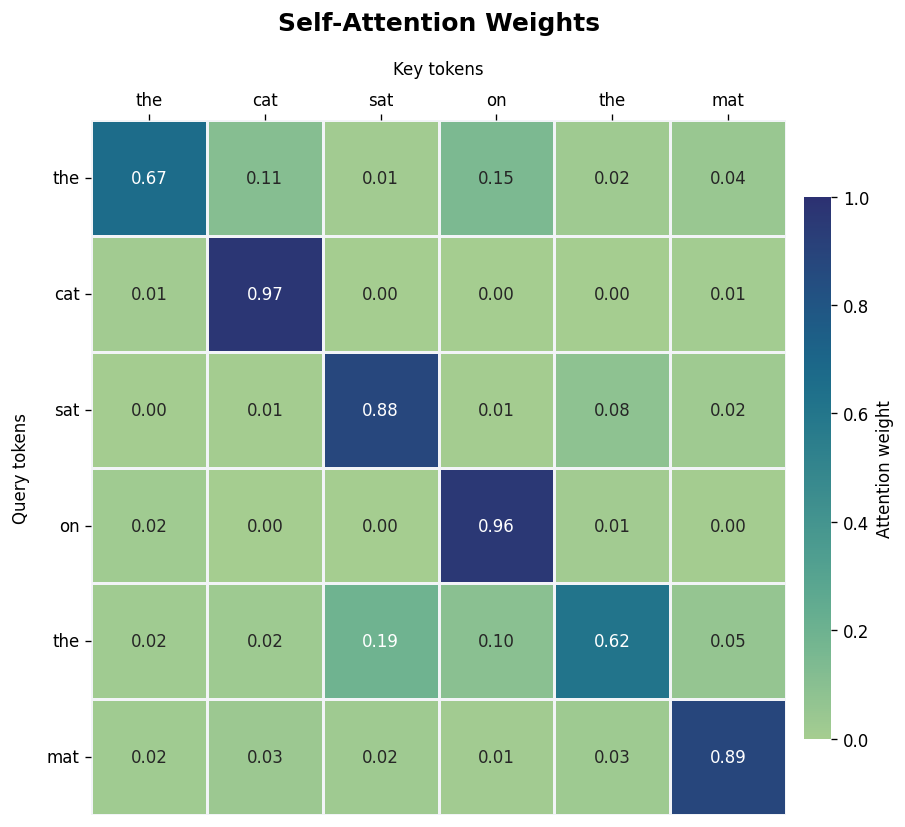

In [17]:
sentence = TASK_2_2_SENTENCE

tokens = sentence.split()
seq_len = len(tokens)

# Create dummy embeddings
d_model = TASK_2_D_MODEL

torch.manual_seed(TASK_2_2_SEED)
embeddings = torch.randn(seq_len, d_model)

# Treat embeddings as Q, K, V
Q = embeddings
K = embeddings
V = embeddings

# Compute Scaled Dot-Product Attention
Q = Q.unsqueeze(0).unsqueeze(0)
K = K.unsqueeze(0).unsqueeze(0)
V = V.unsqueeze(0).unsqueeze(0)

output, attention_weights = scaled_dot_product_attention(Q, K, V)
attention_matrix = attention_weights.squeeze(0).squeeze(0).detach().numpy()
attention_df = pd.DataFrame(attention_matrix, index=tokens, columns=tokens)

# Plot attention heatmap
fig, ax = plt.subplots(figsize=(8.5, 7), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sns.heatmap(
    attention_df,
    cmap=ATTENTION_CMAP,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor=ATTENTION_GRID_COLOR,
    cbar_kws={"label": "Attention weight", "shrink": 0.78, "pad": 0.02},
    annot_kws={"size": 10},
    ax=ax,
)

ax.set_title("Self-Attention Weights", fontsize=15, fontweight="bold", pad=18)
ax.set_xlabel("Key tokens", labelpad=10)
ax.set_ylabel("Query tokens", labelpad=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

print("Tokens:", tokens)
print("Attention matrix shape:", attention_matrix.shape)
print("Attention row sums:", attention_weights.sum(dim=-1))

plt.show()

### **Task 2.3 Experiments (15 points)**

**Experiment 1 — Change One Word:**

1. Use a simple sentence, for example:
    the cat sat on the mat
2. Compute and plot the attention weights as a heatmap.
3. Change one word in the sentence, for example:
    the dog sat on the mat
4. Recompute and plot the attention heatmap.
5. Compare the two heatmaps and explain whether the attention pattern changed.

**Experiment 2 — Compare Different Attention Heads:**

Repeat the attention visualization using at least two different attention heads.

For each head, create separate projection matrices:

$$W_Q, W_K, W_V$$

Use them to compute:
$$Q=XW_Q, K=XW_K, V=XW_V$$

Then compute and plot the attention weights for each head.

**Questions**

Answer briefly:

1. Did changing one word affect the attention weights? Why or why not?
2. Do different attention heads focus on different tokens?
3. Why might multi-head attention be useful in Transformer models?

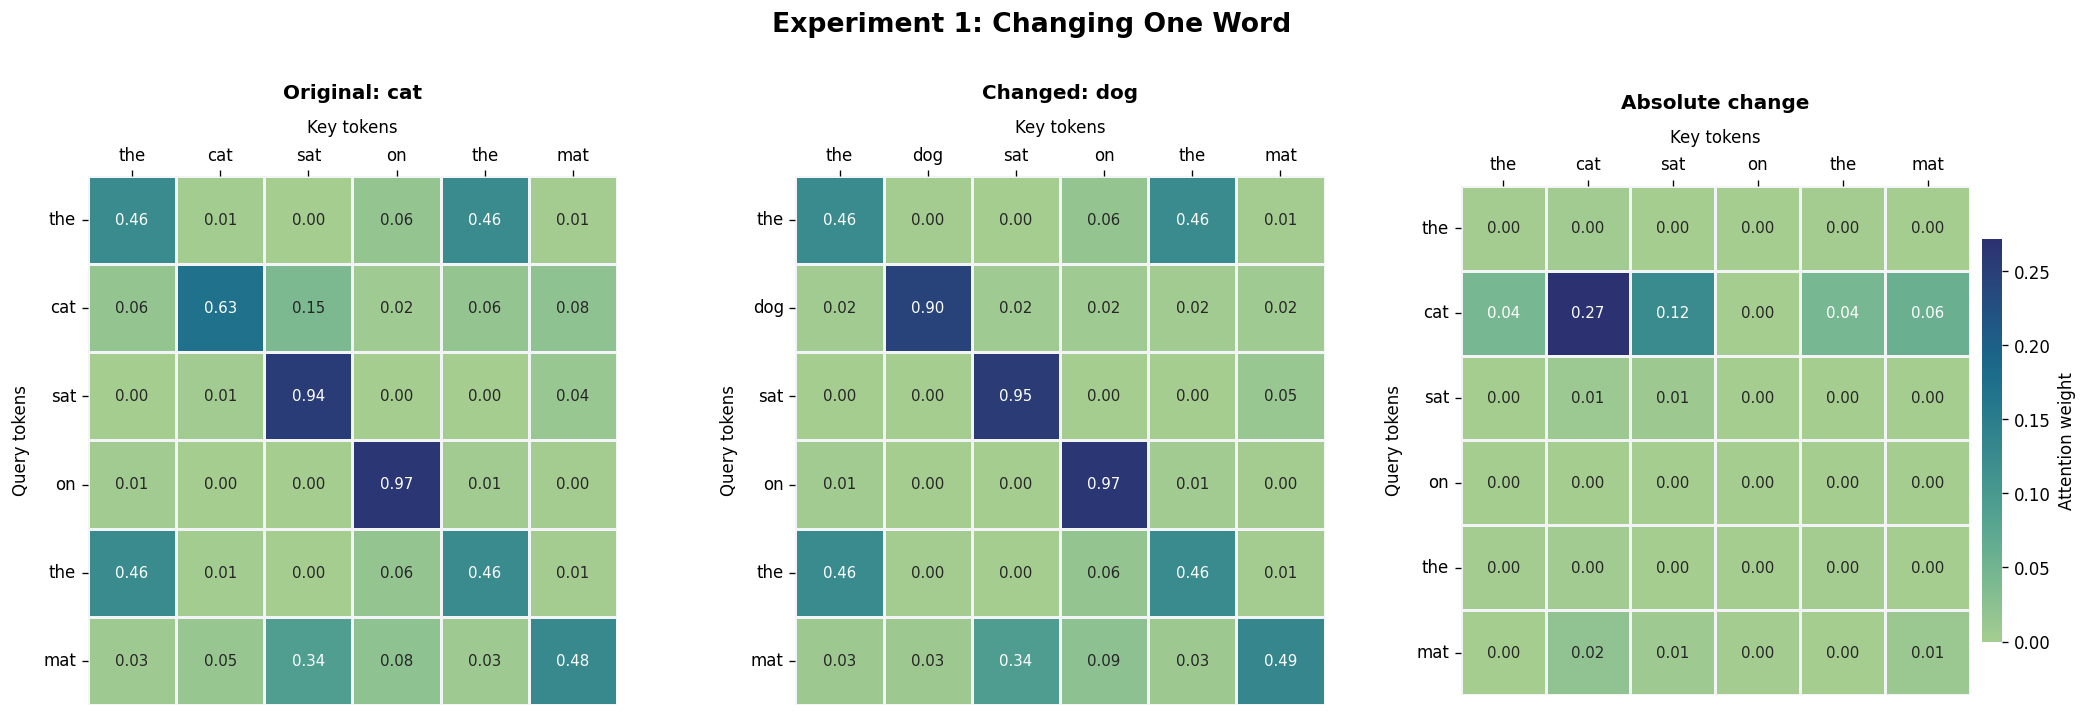

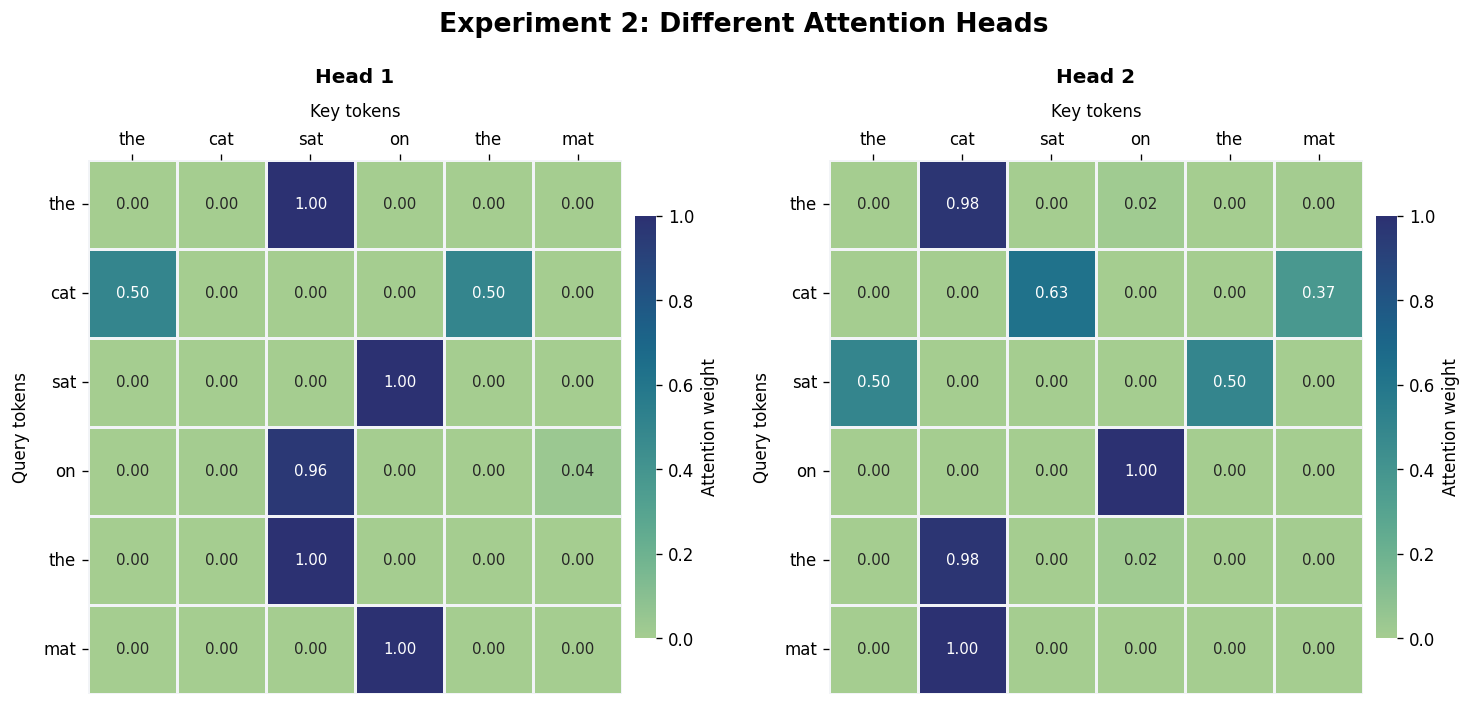

Mean absolute attention difference after changing one word: 0.0172
Maximum absolute attention difference after changing one word: 0.2715
Most attended key token per query for each head:
{'head': 1, 'focused_key_tokens_by_query': ['sat', 'the', 'on', 'sat', 'sat', 'on']}
{'head': 2, 'focused_key_tokens_by_query': ['cat', 'sat', 'the', 'on', 'cat', 'cat']}


In [18]:
torch.manual_seed(TASK_2_3_SEED)

def build_embedding_table(sentences, d_model=TASK_2_D_MODEL):
    vocab = sorted({token for sentence in sentences for token in sentence.split()})
    return {token: torch.randn(d_model) for token in vocab}

def sentence_embeddings(sentence, embedding_table):
    tokens = sentence.split()
    embeddings = torch.stack([embedding_table[token] for token in tokens])
    return tokens, embeddings

def attention_matrix_from_embeddings(embeddings):
    Q = embeddings.unsqueeze(0).unsqueeze(0)
    K = embeddings.unsqueeze(0).unsqueeze(0)
    V = embeddings.unsqueeze(0).unsqueeze(0)
    _, attention_weights = scaled_dot_product_attention(Q, K, V)
    return attention_weights.squeeze(0).squeeze(0)

def plot_attention(ax, matrix, tokens, title, cmap=ATTENTION_CMAP, vmin=0, vmax=1, cbar=True):
    data = pd.DataFrame(matrix.detach().numpy(), index=tokens, columns=tokens)
    sns.heatmap(
        data,
        cmap=cmap,
        annot=True,
        fmt=".2f",
        vmin=vmin,
        vmax=vmax,
        square=True,
        linewidths=0.8,
        linecolor=ATTENTION_GRID_COLOR,
        cbar=cbar,
        cbar_kws={"label": "Attention weight", "shrink": 0.76, "pad": 0.02},
        annot_kws={"size": 9},
        ax=ax,
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel("Key tokens", labelpad=8)
    ax.set_ylabel("Query tokens", labelpad=8)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    for spine in ax.spines.values():
        spine.set_visible(False)


# Experiment 1: change one word
sentence_a = TASK_2_3_SENTENCE_A
sentence_b = TASK_2_3_SENTENCE_B
embedding_table = build_embedding_table([sentence_a, sentence_b])

tokens_a, embeddings_a = sentence_embeddings(sentence_a, embedding_table)
tokens_b, embeddings_b = sentence_embeddings(sentence_b, embedding_table)

attention_a = attention_matrix_from_embeddings(embeddings_a)
attention_b = attention_matrix_from_embeddings(embeddings_b)
attention_difference = (attention_a - attention_b).abs()

diff_max = max(attention_difference.max().item(), 1e-6)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.7), dpi=120)
fig.patch.set_facecolor("white")
fig.suptitle("Experiment 1: Changing One Word", fontsize=16, fontweight="bold", y=1.04)
plot_attention(axes[0], attention_a, tokens_a, "Original: cat", cbar=False)
plot_attention(axes[1], attention_b, tokens_b, "Changed: dog", cbar=False)
plot_attention(
    axes[2],
    attention_difference,
    tokens_a,
    "Absolute change",
    cmap=ATTENTION_DIFF_CMAP,
    vmin=0,
    vmax=diff_max,
    cbar=True,
)
plt.tight_layout()
plt.show()


# Experiment 2: compare two attention heads
d_model = embeddings_a.size(-1)
d_head = TASK_2_3_D_HEAD
num_heads = TASK_2_3_NUM_HEADS
head_matrices = []

for head_index in range(num_heads):
    W_Q = torch.randn(d_model, d_head)
    W_K = torch.randn(d_model, d_head)
    W_V = torch.randn(d_model, d_head)

    Q = (embeddings_a @ W_Q).unsqueeze(0).unsqueeze(0)
    K = (embeddings_a @ W_K).unsqueeze(0).unsqueeze(0)
    V = (embeddings_a @ W_V).unsqueeze(0).unsqueeze(0)
    _, head_attention = scaled_dot_product_attention(Q, K, V)
    head_matrices.append(head_attention.squeeze(0).squeeze(0))

fig, axes = plt.subplots(1, num_heads, figsize=(12.5, 5.7), dpi=120)
fig.patch.set_facecolor("white")
fig.suptitle("Experiment 2: Different Attention Heads", fontsize=16, fontweight="bold", y=1.04)
for head_index, matrix in enumerate(head_matrices):
    plot_attention(axes[head_index], matrix, tokens_a, f"Head {head_index + 1}", cbar=True)
plt.tight_layout()
plt.show()

head_focus = []
for head_index, matrix in enumerate(head_matrices):
    focused_tokens = [tokens_a[index] for index in matrix.argmax(dim=-1).tolist()]
    head_focus.append({"head": head_index + 1, "focused_key_tokens_by_query": focused_tokens})

print("Mean absolute attention difference after changing one word:", round(attention_difference.mean().item(), 4))
print("Maximum absolute attention difference after changing one word:", round(attention_difference.max().item(), 4))
print("Most attended key token per query for each head:")
for item in head_focus:
    print(item)

### Task 2.3 Answer

1. **Did changing one word affect the attention weights? Why or why not?**

   Yes. Changing `cat` to `dog` changed one token embedding, which changed the dot products between queries and keys. In this rerun, the mean absolute attention difference was `0.0172`, and the maximum absolute difference was `0.2715`. The largest changes appeared around rows and columns connected to the replaced token.

2. **Do different attention heads focus on different tokens?**

   Yes. The two heads used different projection matrices, so they produced different attention patterns. In this rerun, Head 1 focused on key tokens `sat`, `the`, `on`, `sat`, `sat`, `on` across the six query positions. Head 2 focused on `cat`, `sat`, `the`, `on`, `cat`, `cat`.

3. **Why might multi-head attention be useful in Transformer models?**

   Multi-head attention is useful because each head can represent a different relationship between tokens. One head can focus on syntactic structure, another on repeated or semantically important words, and another on longer-range context. Combining the heads gives the model a richer representation than a single attention map.
